# Dynamic Hedge Ratio and Residual Trading

## 1. imports and settings

In [1]:
from pathlib import Path
from dataclasses import dataclass
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display

from quantfinlab.risk import (
    nav_series,
    performance_table,
    rolling_volatility,
    drawdown_series,
    drawdown_summary_table,
    historical_es,
    hist_var_es,
    var_es_table,
    rolling_corr,
    rolling_beta,
    capm_ols,
    stress_table,
)
from quantfinlab.portfolio.universe import prices_to_returns
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.plotting.risk import auto_grid, turn_off_unused_axes
from quantfinlab.plotting.portfolio import plot_turnover_bar, plot_metric_bar

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

In [2]:
start = "2015-01-01"
end = "2026-01-01"
ann = 252
n_train = 504
win = 252
alpha = 10.0
freq = "w-fri"
band = 0.05
cost_bps = 5.0
z_win = 126
z_in = 2.0
z_out = 0.5
z_stop = 3.5
z_cool = 5

## 2. load and clean data

In [3]:
etf_path = Path("../data/ETF_data.csv")
nasdaq_path = Path("../data/nasdaq_all_close_volume.parquet")

etf_px = load_yfinance_panel(etf_path, fields=("close",), start=start, end=end, lowercase=True)["close"]
stock_px = load_yfinance_panel(nasdaq_path, fields=("close",), start=start, end=end, lowercase=True)["close"]

px = pd.concat([stock_px, etf_px], axis=1)
px = px.loc[:, ~px.columns.duplicated(keep="last")]
px = px.loc[(px.index >= start) & (px.index <= end)].sort_index()

ret_m = prices_to_returns(px, kind="log")
ret_b = prices_to_returns(px, kind="simple")

print(f"etf close panel: {etf_px.shape}")
print(f"stock close panel: {stock_px.shape}")
print(f"combined price panel from {start} to {end}: {px.shape}")


etf close panel: (2766, 63)
stock close panel: (2766, 4382)
combined price panel from 2015-01-01 to 2026-01-01: (2766, 4445)


## 3. main hedge relationships

In [4]:
@dataclass(frozen=True)
class rel:
    name: str
    target: str
    hedges: list[str]
    desc: str = ""
    pair: tuple[str, str] | None = None

    def __post_init__(self):
        object.__setattr__(self, "name", self.name.lower())
        object.__setattr__(self, "target", self.target.lower())
        object.__setattr__(self, "hedges", [h.lower() for h in self.hedges])
        if self.pair is not None:
            object.__setattr__(self, "pair", tuple(x.lower() for x in self.pair))

    @property
    def assets(self):
        return [self.target, *self.hedges]

    @property
    def hedge_label(self):
        return "+".join(self.hedges)


def rel_tickers(rels):
    out = []
    for r in rels:
        for t in r.assets:
            if t not in out:
                out.append(t)
    return out


def filter_rels(rels, columns):
    available = set(map(str.lower, columns))
    kept, missing = [], {}
    for r in rels:
        miss = [t for t in r.assets if t not in available]
        if miss:
            missing[r.name] = miss
        else:
            kept.append(r)
    return kept, missing


def rel_table(rels, columns):
    available = set(map(str.lower, columns))
    rows = []
    for r in rels:
        rows.append({
            "relationship": r.name,
            "target": r.target,
            "hedges": ", ".join(r.hedges),
            "description": r.desc,
            "residual_pair": "" if r.pair is None else " / ".join(r.pair),
            "included": all(t in available for t in r.assets),
        })
    return pd.DataFrame(rows)


In [5]:
rel_main = [
    rel("qqq_spy", "qqq", ["spy"], "nasdaq growth hedged by broad market", pair=("qqq", "spy")),
    rel("tlt_ief", "tlt", ["ief"], "long duration hedged by intermediate duration", pair=("tlt", "ief")),
    rel("agg_bnd", "agg", ["bnd"], "aggregate bond etf hedged by close aggregate bond substitute", pair=("agg", "bnd")),
    rel("hyg_credit", "hyg", ["lqd", "tlt", "spy"], "high yield credit hedged by credit, duration, and equity beta", pair=("hyg", "lqd")),
    rel("gdx_gold", "gdx", ["gld", "spy"], "gold miners hedged by gold and equity beta", pair=("gdx", "gld")),
    rel("nvda_semi", "nvda", ["smh", "qqq"], "nvidia hedged by semiconductors and growth"),
    rel("amd_semi", "amd", ["smh", "qqq"], "amd hedged by semiconductors and growth"),
    rel("aapl_tech", "aapl", ["xlk", "qqq"], "apple hedged by technology and growth"),
    rel("msft_tech", "msft", ["xlk", "qqq"], "microsoft hedged by technology and growth"),
    rel("amzn_disc", "amzn", ["xly", "qqq"], "amazon hedged by discretionary and growth"),
    rel("tsla_disc", "tsla", ["xly", "qqq"], "tesla hedged by discretionary and growth"),
    rel("cost_def", "cost", ["xlp", "qqq"], "costco hedged by staples and growth")
]

rel_view = rel_table(rel_main, px.columns)
rel_main, missing_main = filter_rels(rel_main, px.columns)
tickers_main = rel_tickers(rel_main)

if missing_main:
    display(pd.Series({k: ", ".join(v) for k, v in missing_main.items()}, name="missing_tickers").to_frame())
else:
    print("missing main relationship tickers: none")

display(rel_view)

px_main = px[tickers_main]
ret_m_main = ret_m[tickers_main]
ret_b_main = ret_b[tickers_main]

missing main relationship tickers: none


,relationship,target,hedges,description,residual_pair,included
0,qqq_spy,qqq,spy,nasdaq growth hedged by broad market,qqq / spy,True
1,tlt_ief,tlt,ief,long duration hedged by intermediate duration,tlt / ief,True
2,agg_bnd,agg,bnd,aggregate bond etf hedged by close aggregate b...,agg / bnd,True
3,hyg_credit,hyg,"lqd, tlt, spy","high yield credit hedged by credit, duration, ...",hyg / lqd,True
4,gdx_gold,gdx,"gld, spy",gold miners hedged by gold and equity beta,gdx / gld,True
5,nvda_semi,nvda,"smh, qqq",nvidia hedged by semiconductors and growth,,True
6,amd_semi,amd,"smh, qqq",amd hedged by semiconductors and growth,,True
7,aapl_tech,aapl,"xlk, qqq",apple hedged by technology and growth,,True
8,msft_tech,msft,"xlk, qqq",microsoft hedged by technology and growth,,True
9,amzn_disc,amzn,"xly, qqq",amazon hedged by discretionary and growth,,True


## 4. diagnostics before modeling

,relationship,target,hedges,description,start,end,obs,missing_pct,included
0,qqq_spy,qqq,spy,nasdaq growth hedged by broad market,2015-01-02,2025-12-31,2766,0.0,True
1,tlt_ief,tlt,ief,long duration hedged by intermediate duration,2015-01-02,2025-12-31,2766,0.0,True
2,agg_bnd,agg,bnd,aggregate bond etf hedged by close aggregate b...,2015-01-02,2025-12-31,2766,0.0,True
3,hyg_credit,hyg,"lqd, tlt, spy","high yield credit hedged by credit, duration, ...",2015-01-02,2025-12-31,2766,0.0,True
4,gdx_gold,gdx,"gld, spy",gold miners hedged by gold and equity beta,2015-01-02,2025-12-31,2766,0.0,True
5,nvda_semi,nvda,"smh, qqq",nvidia hedged by semiconductors and growth,2015-01-02,2025-12-31,2766,0.0,True
6,amd_semi,amd,"smh, qqq",amd hedged by semiconductors and growth,2015-01-02,2025-12-31,2766,0.0,True
7,aapl_tech,aapl,"xlk, qqq",apple hedged by technology and growth,2015-01-02,2025-12-31,2766,0.0,True
8,msft_tech,msft,"xlk, qqq",microsoft hedged by technology and growth,2015-01-02,2025-12-31,2766,0.0,True
9,amzn_disc,amzn,"xly, qqq",amazon hedged by discretionary and growth,2015-01-02,2025-12-31,2766,0.0,True


,relationship,target_vol,hedge_vol,corr,r2,beta_iqr,obs
0,qqq_spy,0.2201,0.1783,0.9338,0.8720,0.1542,2765
1,tlt_ief,0.1503,0.0663,0.9161,0.8392,0.2819,2765
2,agg_bnd,0.0525,0.0537,0.9585,0.9186,0.0749,2765
3,hyg_credit,0.0831,0.0928,0.6639,0.4408,0.2040,2765
4,gdx_gold,0.3822,0.1182,0.6194,0.3837,0.8500,2765
5,nvda_semi,0.4836,0.2585,0.8094,0.6551,0.3215,2765
6,amd_semi,0.5782,0.2585,0.6392,0.4086,0.4010,2765
7,aapl_tech,0.2881,0.2273,0.8134,0.6617,0.1668,2765
8,msft_tech,0.2686,0.2273,0.8596,0.7388,0.1301,2765
9,amzn_disc,0.3280,0.2117,0.7675,0.5891,0.1924,2765


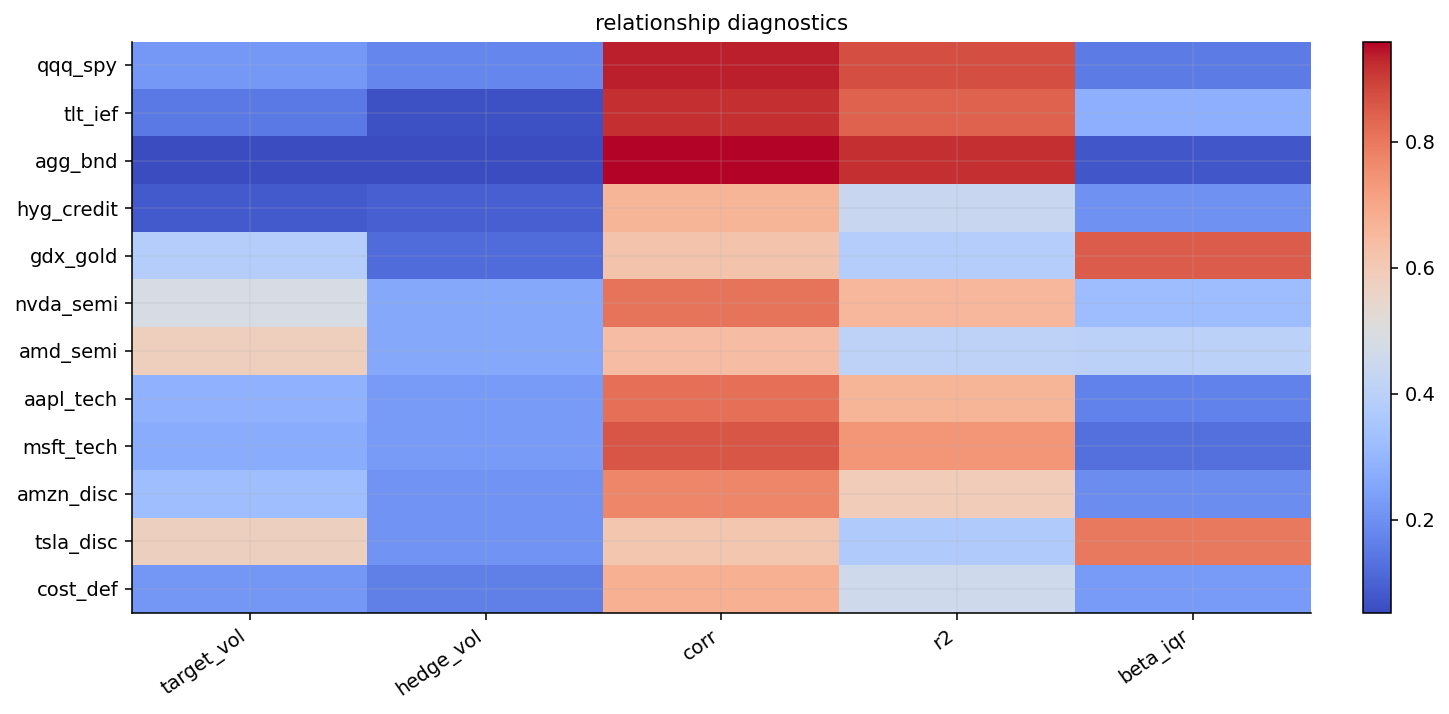

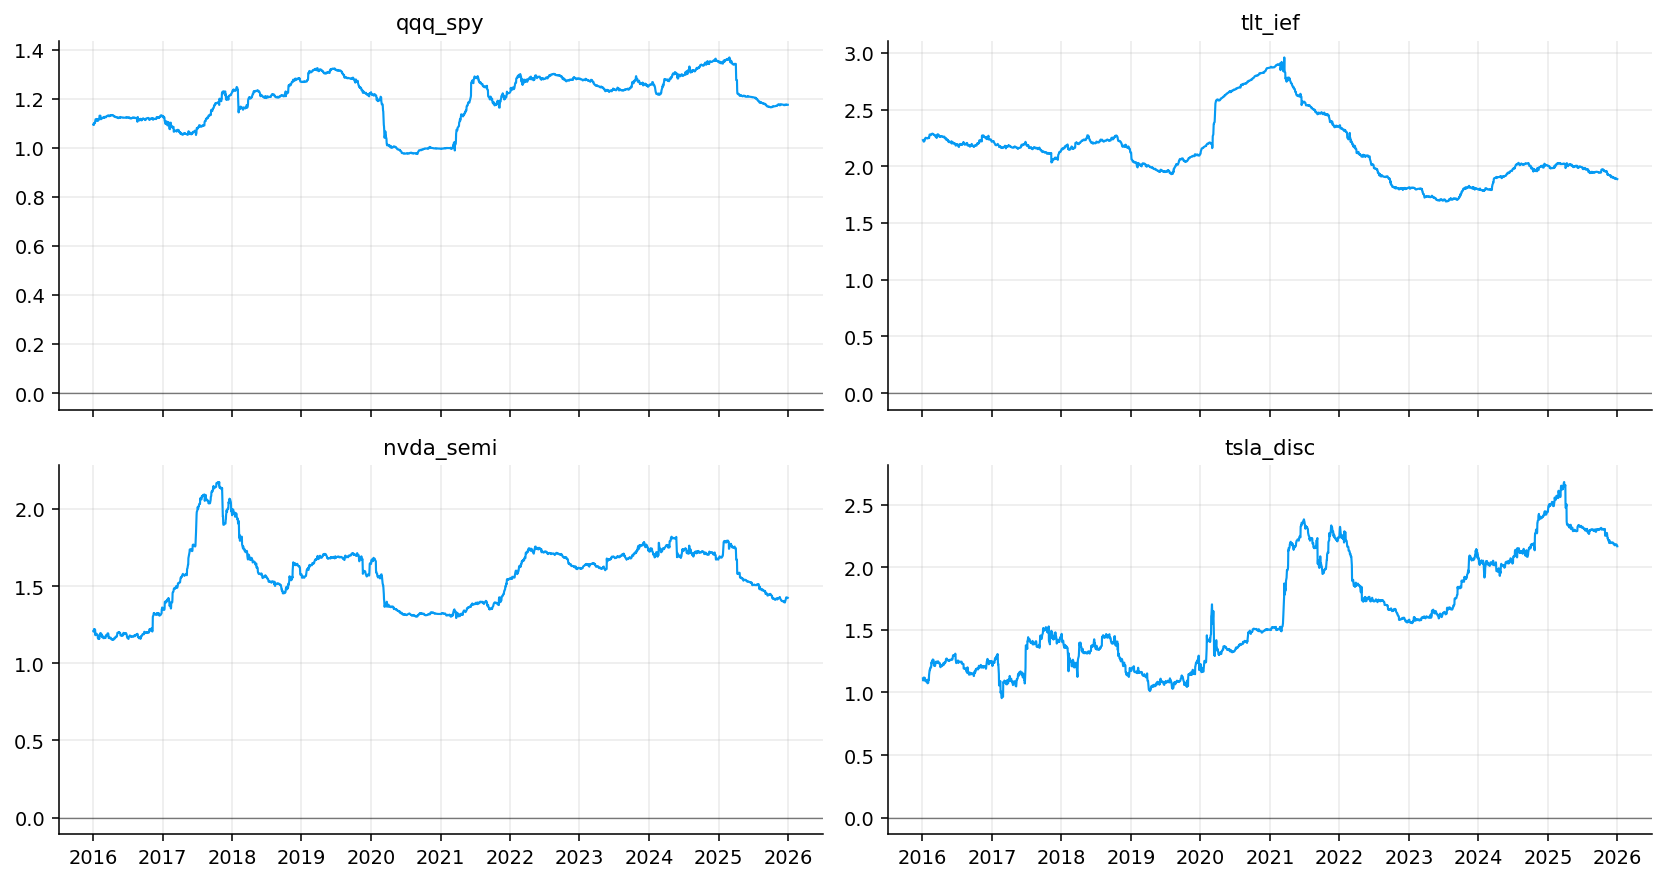

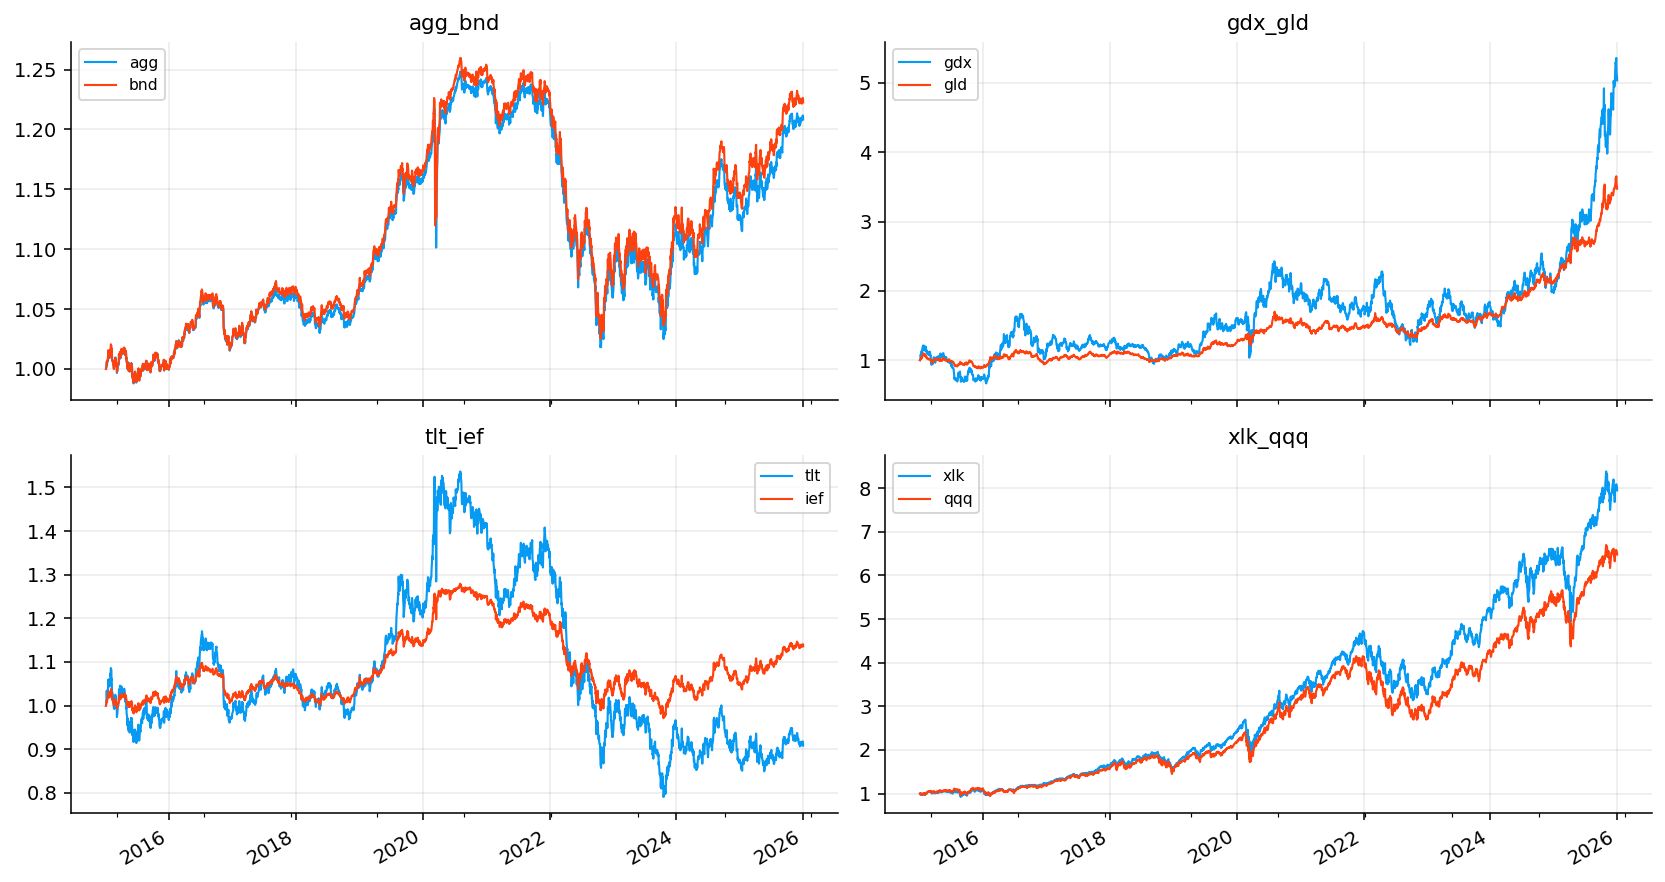

In [6]:
def hedge_proxy_ret(ret, r):
    return ret[r.hedges].mean(axis=1).rename(f"{r.name}_proxy")


def coverage_table(frame, rels):
    rows = []
    for r in rels:
        sub = frame[r.assets]
        valid = sub.dropna(how="any")
        rows.append({
            "relationship": r.name,
            "target": r.target,
            "hedges": ", ".join(r.hedges),
            "description": r.desc,
            "start": valid.index.min() if len(valid) else pd.NaT,
            "end": valid.index.max() if len(valid) else pd.NaT,
            "obs": len(valid),
            "missing_pct": sub.isna().mean().mean(),
            "included": len(valid) > 0,
        })
    return pd.DataFrame(rows)


def diag_table(ret, rels):
    rows = []
    for r in rels:
        y = ret[r.target]
        proxy = hedge_proxy_ret(ret, r)
        z = pd.concat([y, proxy], axis=1).dropna()
        z.columns = ["target", "proxy"]
        _, _, r2 = capm_ols(z["target"], z["proxy"])
        b = rolling_beta(z["target"], z["proxy"], window=min(win, max(len(z) // 2, 20)))
        rows.append({
            "relationship": r.name,
            "target_vol": z["target"].std() * np.sqrt(ann),
            "hedge_vol": z["proxy"].std() * np.sqrt(ann),
            "corr": z["target"].corr(z["proxy"]),
            "r2": r2,
            "beta_iqr": b.quantile(0.75) - b.quantile(0.25),
            "obs": len(z),
        })
    return pd.DataFrame(rows)


tab_cov = coverage_table(px_main, rel_main)
tab_diag = diag_table(ret_m_main, rel_main)
display(tab_cov.round(4))
display(tab_diag.round(4))

fig, ax = plt.subplots(figsize=(10.5, 5.2))
mat = tab_diag.set_index("relationship")[["target_vol", "hedge_vol", "corr", "r2", "beta_iqr"]]
im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
ax.set_xticks(range(mat.shape[1]), mat.columns, rotation=35, ha="right")
ax.set_yticks(range(mat.shape[0]), mat.index)
ax.set_title("relationship diagnostics")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, name in zip(axes.ravel(), ["qqq_spy", "tlt_ief", "nvda_semi", "tsla_disc"]):
    r = next((x for x in rel_main if x.name == name), None)
    if r is None:
        ax.axis("off")
        continue
    b = rolling_beta(ret_m_main[r.target], hedge_proxy_ret(ret_m_main, r), window=win).dropna()
    ax.plot(b.index, b.values, lw=1.1)
    ax.axhline(0, color="black", lw=0.7, alpha=0.5)
    ax.set_title(name)
    ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

price_examples = [("agg_bnd", "agg", "bnd"), ("gdx_gld", "gdx", "gld"), ("tlt_ief", "tlt", "ief"), ("xlk_qqq", "xlk", "qqq")]
price_examples = [(name, a, b) for name, a, b in price_examples if a in px.columns and b in px.columns]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, item in zip(axes.ravel(), price_examples):
    name, a, b = item
    sub = px[[a, b]].dropna()
    if len(sub):
        (sub / sub.iloc[0]).plot(ax=ax, lw=1.1)
    ax.set_title(name)
    ax.grid(True, alpha=0.25)
for ax in axes.ravel()[len(price_examples):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. static ols

Static ols estimates one hedge ratio on the initial training window and uses it unchanged out of sample.

In [7]:
def ols_fit(y, x):
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1)
    xmat = np.column_stack([np.ones(len(y)), x])
    coef = np.linalg.lstsq(xmat, y, rcond=None)[0]
    return float(coef[0]), np.asarray(coef[1:], dtype=float)


def ols_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    if len(z) < n_train:
        return out
    _, b = ols_fit(z[r.target].iloc[:n_train], z[r.hedges].iloc[:n_train])
    out.loc[z.index[n_train - 1]:, r.hedges] = b
    return out


def rebalance_beta(beta, index):
    idx = pd.DatetimeIndex(index).sort_values()
    daily = beta.reindex(idx.union(beta.index)).sort_index().ffill().reindex(idx)
    dates = pd.Series(idx, index=idx).groupby(pd.Grouper(freq=freq.upper())).last().dropna()
    return daily.loc[pd.DatetimeIndex(dates.values)].dropna(how="all") if len(dates) else pd.DataFrame(columns=beta.columns)


def zero_beta(index, r):
    return pd.DataFrame(0.0, index=pd.DatetimeIndex(index)[:1], columns=r.hedges)


def hedge_book(ret, r, beta, cost_bps=cost_bps):
    panel = ret[r.assets].dropna()
    b = beta.reindex(panel.index.union(beta.index)).sort_index().ffill().reindex(panel.index)
    b = b.shift(1).dropna(how="any")
    panel = panel.reindex(b.index).dropna(how="any")
    b = b.reindex(panel.index)
    gross = panel[r.target] - (b[r.hedges] * panel[r.hedges]).sum(axis=1)
    turnover = b.diff().abs().sum(axis=1)
    if len(turnover):
        turnover.iloc[0] = b.iloc[0].abs().sum()
    cost = turnover * cost_bps / 10000.0
    net = gross - cost
    return {
        "target_return": panel[r.target],
        "gross_return": gross,
        "net_return": net,
        "turnover": turnover,
        "cost": cost,
        "beta": b,
        "gross_values": (1 + gross).cumprod(),
        "net_values": (1 + net).cumprod(),
        "target_values": (1 + panel[r.target]).cumprod(),
    }


class book_result:
    def __init__(self, d):
        self.__dict__.update(d)
        self.net_returns = d["net_return"]
        self.gross_returns = d["gross_return"]


def total_return(s):
    x = pd.Series(s).dropna()
    return float(x.iloc[-1] / x.iloc[0] - 1) if len(x) > 1 and abs(x.iloc[0]) > 1e-12 else np.nan


def maxdd(ret):
    s = pd.Series(ret).dropna()
    return float(drawdown_series(s, input_kind="returns").min()) if len(s) else np.nan


def model_table(bt, rels, ret):
    rows = []
    for r in rels:
        base_name = f"{r.name} | target"
        base = bt[base_name].net_returns
        proxy = hedge_proxy_ret(ret, r)
        zbase = pd.concat([base, proxy], axis=1).dropna()
        _, beta_base, _ = capm_ols(zbase.iloc[:, 0], zbase.iloc[:, 1]) if len(zbase) >= 3 else (np.nan, np.nan, np.nan)
        for name, res in bt.items():
            if not name.startswith(f"{r.name} | ") or name == base_name:
                continue
            model = name.split(" | ", 1)[1]
            z = pd.concat([base.rename("base"), res.net_returns.rename("model")], axis=1).dropna()
            if len(z) < 5:
                continue
            vol_base = z["base"].std() * np.sqrt(ann)
            vol_model = z["model"].std() * np.sqrt(ann)
            es_base = historical_es(z["base"], alpha=0.05)
            es_model = historical_es(z["model"], alpha=0.05)
            zbeta = pd.concat([res.net_returns, proxy], axis=1).dropna()
            _, beta_model, _ = capm_ols(zbeta.iloc[:, 0], zbeta.iloc[:, 1]) if len(zbeta) >= 3 else (np.nan, np.nan, np.nan)
            bpath = res.beta[r.hedges] if hasattr(res, "beta") and not res.beta.empty else pd.DataFrame()
            b_iqr = bpath.quantile(0.75).sub(bpath.quantile(0.25)).mean() if not bpath.empty else np.nan
            b_jump = bpath.diff().abs().mean().mean() if not bpath.empty else np.nan
            cost_s = pd.Series(getattr(res, "cost", pd.Series(dtype=float)), dtype=float)
            rows.append({
                "relationship": r.name,
                "model": model,
                "vol_red": 1 - vol_model / vol_base if vol_base > 1e-12 else np.nan,
                "es_red": 1 - abs(es_model) / abs(es_base) if abs(es_base) > 1e-12 else np.nan,
                "maxdd_diff": abs(maxdd(z["base"])) - abs(maxdd(z["model"])),
                "beta_red": 1 - abs(beta_model) / abs(beta_base) if abs(beta_base) > 1e-12 else np.nan,
                "turnover": res.turnover.mean() if len(res.turnover) else 0.0,
                "turnover_ann": res.turnover.mean() * ann if len(res.turnover) else 0.0,
                "cost_drag": max(total_return(res.gross_values) - total_return(res.net_values), 0.0),
                "cost_drag_ann": cost_s.mean() * ann if len(cost_s) else 0.0,
                "beta_iqr": b_iqr,
                "beta_jump": b_jump,
                "beta_stability": 1 / (1 + b_iqr + 5 * b_jump) if np.isfinite(b_iqr) and np.isfinite(b_jump) else np.nan,
                "rebalance_count": int((res.turnover.abs() > 1e-12).sum()) if len(res.turnover) else 0,
            })
    return pd.DataFrame(rows)

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6417,0.6509,0.1496,0.9547,0.1236,0.0001
1,tlt_ief,0.5831,0.5382,0.2007,0.9156,0.2484,0.0001
2,agg_bnd,0.7130,0.8054,0.1456,0.9838,0.1061,0.0001
3,hyg_credit,0.4190,0.4729,0.0073,0.8022,0.1523,0.0001
4,gdx_gold,0.2050,0.2059,-0.4645,0.3172,0.3950,0.0002
5,nvda_semi,0.4428,0.4700,0.1705,0.8676,0.1256,0.0001
6,amd_semi,0.2853,0.2980,-0.0520,0.9804,0.2119,0.0001
7,aapl_tech,0.3972,0.4234,-0.0960,0.8054,0.2021,0.0001
8,msft_tech,0.4482,0.4510,-0.0930,0.7224,0.1370,0.0001
9,amzn_disc,0.3862,0.4278,0.0531,0.9345,0.1405,0.0001


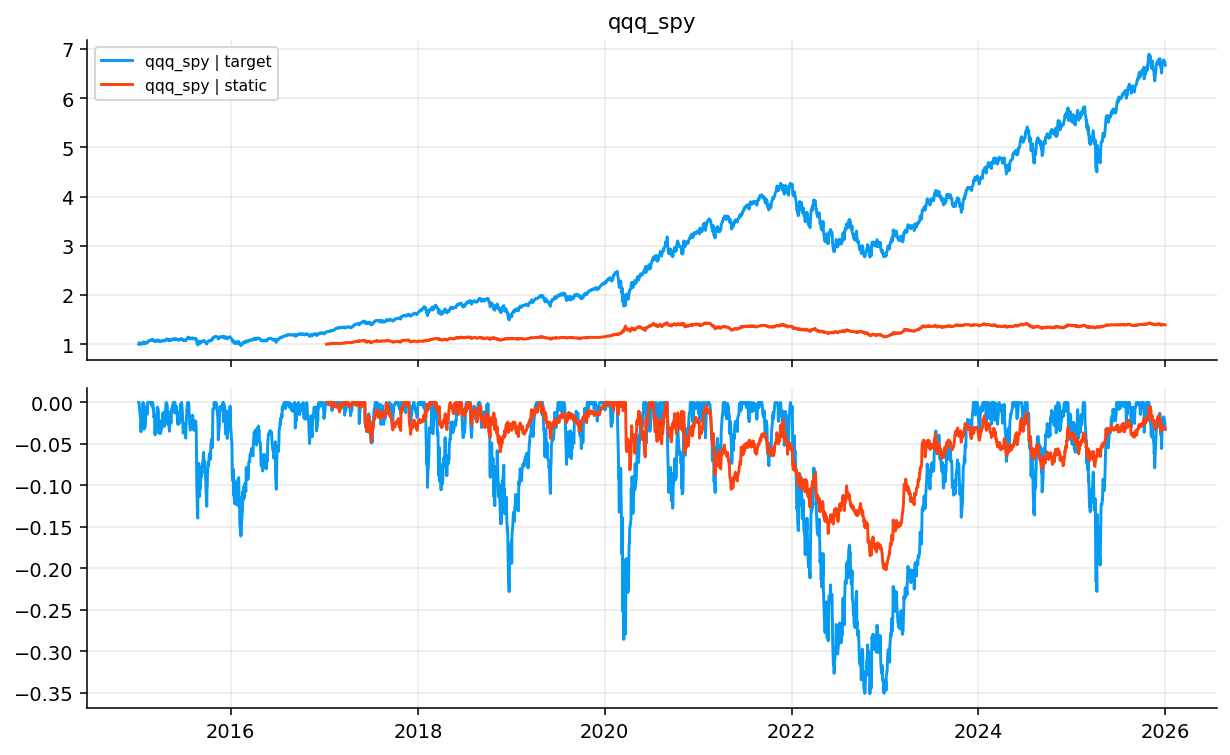

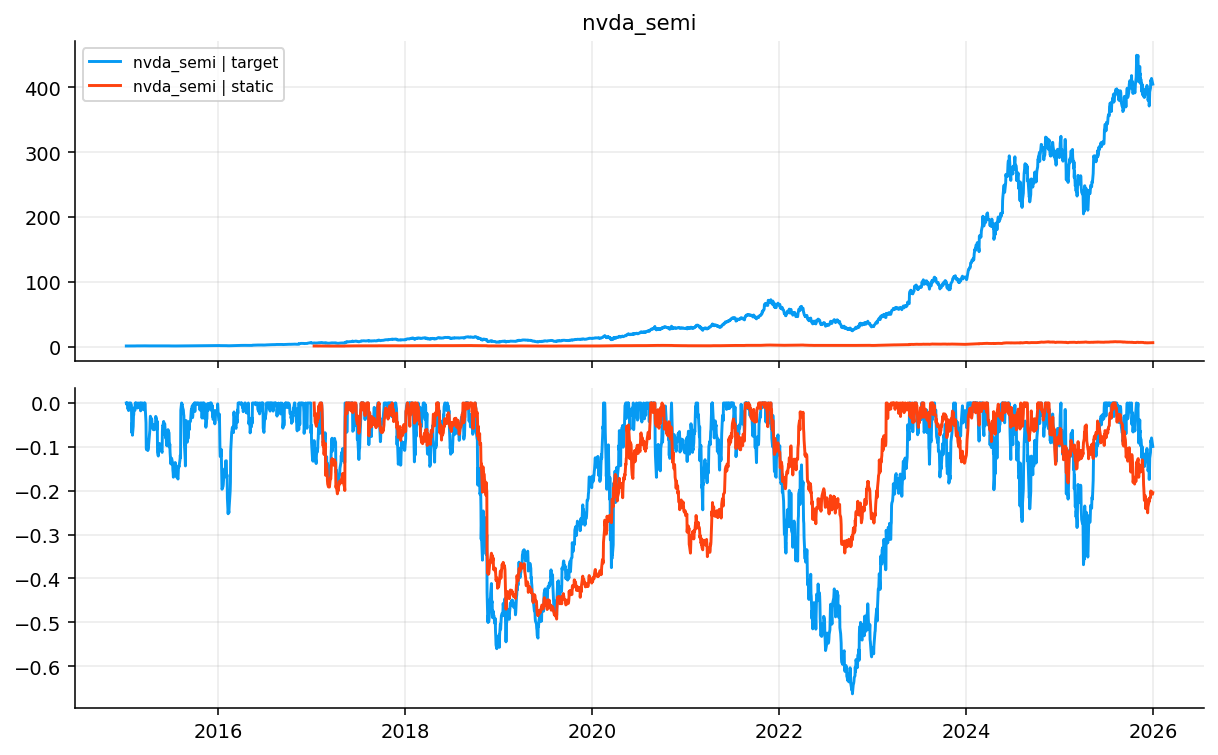

In [8]:
books_target = {f"{r.name} | target": book_result(hedge_book(ret_b_main, r, zero_beta(ret_b_main.index, r))) for r in rel_main}
books_static, blog, beta_daily = {}, {}, {}

for r in rel_main:
    b0 = ols_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index).ffill()
    books_static[f"{r.name} | static"] = book_result(hedge_book(ret_b_main, r, b1))
    blog[f"{r.name} | static"] = {"rel": r.name, "model": "static", "desired": b0, "traded": b1}

bt_static = {**books_target, **books_static}
tab_static = model_table(bt_static, rel_main, ret_m_main)
model_cols = ["relationship", "vol_red", "es_red", "maxdd_diff", "beta_red", "turnover_ann", "cost_drag_ann"]
display(tab_static[model_cols].round(4))

for name in ["qqq_spy", "nvda_semi"]:
    if f"{name} | static" in bt_static:
        fig, axes = plt.subplots(2, 1, figsize=(8.8, 5.5), sharex=True)
        for key in [f"{name} | target", f"{name} | static"]:
            nav = bt_static[key].net_values / bt_static[key].net_values.iloc[0]
            axes[0].plot(nav.index, nav, label=key)
            axes[1].plot(nav.index, drawdown_series(nav, input_kind="nav"), label=key)
        axes[0].set_title(name)
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.25)
        axes[1].grid(True, alpha=0.25)
        plt.tight_layout(); plt.show()

## 6. rolling ols plus band

Rolling ols updates the desired beta. The band turns desired beta into traded beta.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6488,0.6592,0.1628,0.9773,0.2895,0.0001
1,tlt_ief,0.6074,0.5836,0.2297,0.9963,0.6364,0.0003
2,agg_bnd,0.6987,0.8015,0.1379,0.9980,0.1718,0.0001
3,hyg_credit,0.4937,0.5226,0.0639,0.9786,0.8276,0.0004
4,gdx_gold,0.3674,0.3913,-0.2852,0.9591,1.4500,0.0007
5,nvda_semi,0.4610,0.4825,0.1683,0.9792,2.2263,0.0011
6,amd_semi,0.2941,0.3182,-0.0136,0.9933,3.3270,0.0017
7,aapl_tech,0.4416,0.4681,0.0333,0.9964,3.4614,0.0017
8,msft_tech,0.5259,0.5430,0.1728,0.9811,2.1223,0.0011
9,amzn_disc,0.4059,0.4538,0.1401,0.9926,1.8225,0.0009


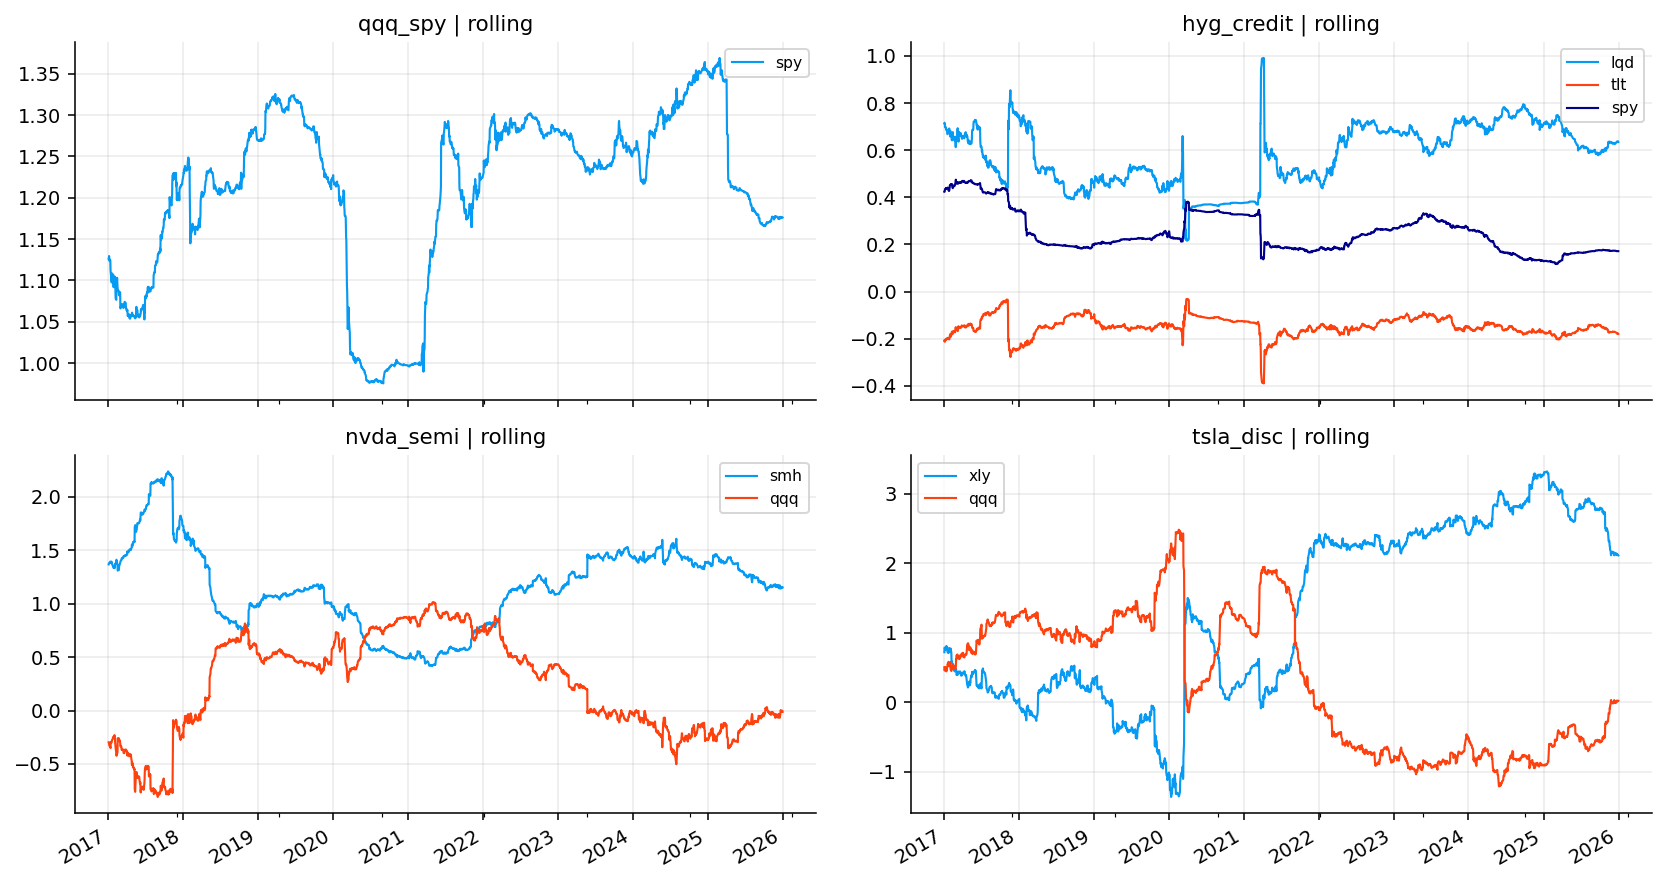

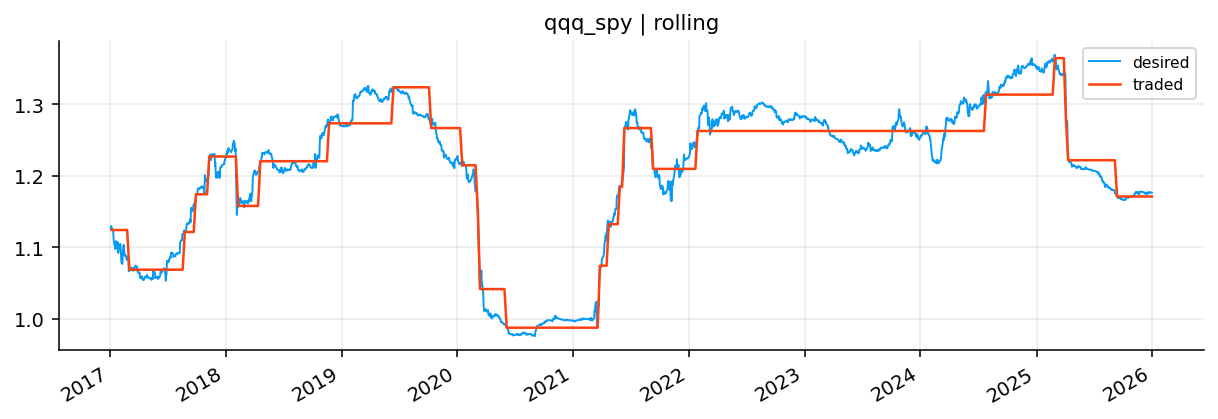

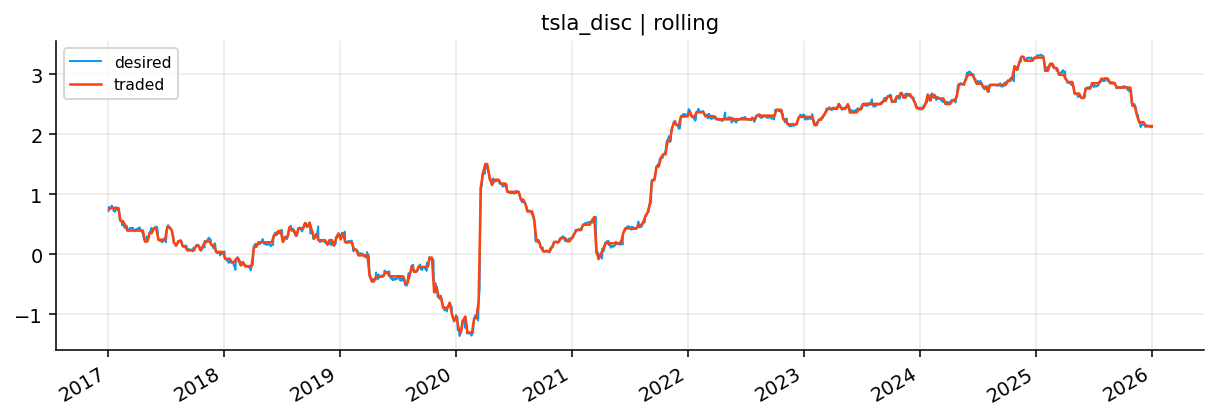

In [9]:
def roll_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    for i in range(max(win, n_train) - 1, len(z)):
        sample = z.iloc[i - win + 1:i + 1]
        _, b = ols_fit(sample[r.target], sample[r.hedges])
        out.loc[z.index[i], r.hedges] = b
    return out


def band_beta(beta, band=band):
    out = pd.DataFrame(np.nan, index=beta.index, columns=beta.columns)
    prev = pd.Series(np.nan, index=beta.columns)
    for dt, row in beta.iterrows():
        if row.notna().sum() == 0:
            out.loc[dt] = prev
            continue
        if prev.notna().sum() == 0:
            prev = row.astype(float)
        else:
            upd = (row - prev).abs() > band
            prev.loc[upd & row.notna()] = row.loc[upd & row.notna()]
        out.loc[dt] = prev
    return out


books_roll = {}
for r in rel_main:
    b0 = roll_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index)
    b2 = band_beta(b1, band=band)
    beta_daily[(r.name, "rolling")] = b0
    books_roll[f"{r.name} | rolling"] = book_result(hedge_book(ret_b_main, r, b2))
    blog[f"{r.name} | rolling"] = {"rel": r.name, "model": "rolling", "desired": b0, "traded": b2}

bt_roll = {**books_target, **books_roll}
tab_roll = model_table(bt_roll, rel_main, ret_m_main)
display(tab_roll[model_cols].round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, name in zip(axes.ravel(), ["qqq_spy", "hyg_credit", "nvda_semi", "tsla_disc"]):
    key = f"{name} | rolling"
    if key in blog:
        blog[key]["desired"].dropna(how="all").plot(ax=ax, lw=1.1)
        ax.set_title(key)
        ax.grid(True, alpha=0.25)
    else:
        ax.axis("off")
plt.tight_layout(); plt.show()

for key in ["qqq_spy | rolling", "tsla_disc | rolling"]:
    if key in blog:
        h = blog[key]["desired"].columns[0]
        fig, ax = plt.subplots(figsize=(8.8, 3.1))
        blog[key]["desired"][h].dropna().plot(ax=ax, label="desired", lw=1.0)
        blog[key]["traded"][h].dropna().plot(ax=ax, label="traded", lw=1.3)
        ax.set_title(key)
        ax.legend()
        ax.grid(True, alpha=0.25)
        plt.tight_layout(); plt.show()

## 7. rolling ridge plus band

Ridge is useful when hedge assets are correlated. It is included for all relationships to keep the tournament uniform.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6491,0.6586,0.1652,0.9835,0.2597,0.0001
1,tlt_ief,0.6061,0.5833,0.2304,0.9658,0.6180,0.0003
2,agg_bnd,0.6889,0.7907,0.1365,0.9711,0.1652,0.0001
3,hyg_credit,0.4862,0.5139,0.0685,0.9374,0.6685,0.0003
4,gdx_gold,0.3689,0.3923,-0.2580,0.9972,1.3368,0.0007
5,nvda_semi,0.4613,0.4859,0.1700,0.9976,1.5870,0.0008
6,amd_semi,0.2955,0.3219,0.0050,0.9871,2.4303,0.0012
7,aapl_tech,0.4397,0.4676,0.0575,0.9754,1.1579,0.0006
8,msft_tech,0.5268,0.5473,0.1770,0.9921,0.6578,0.0003
9,amzn_disc,0.4048,0.4525,0.1300,0.9723,1.3917,0.0007


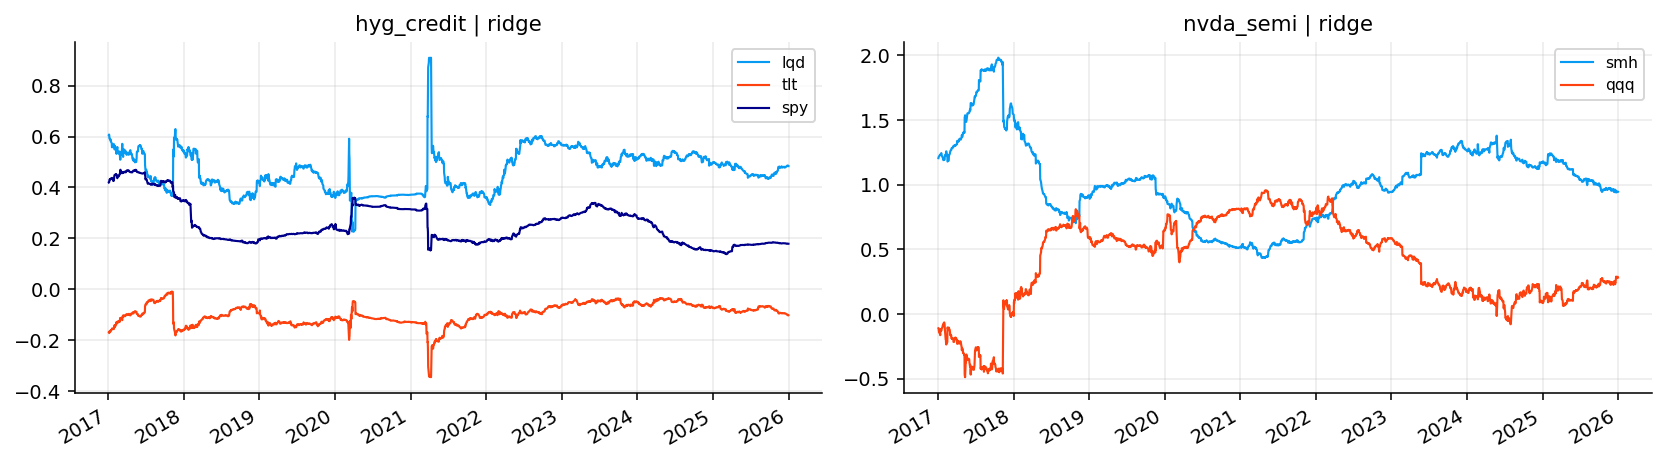

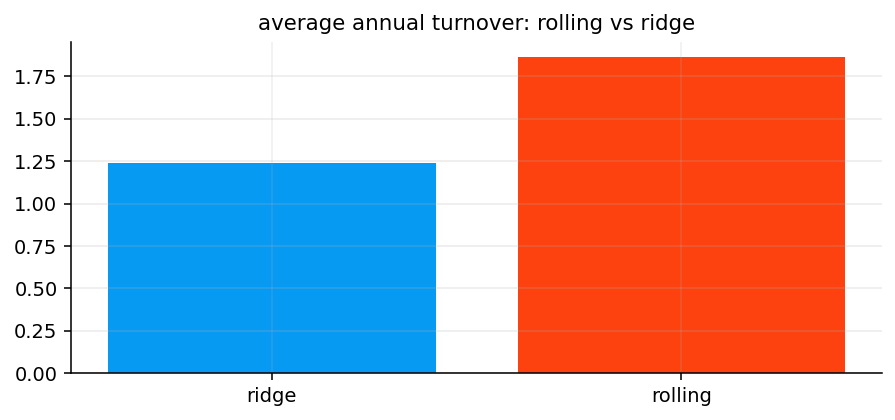

In [10]:
def ridge_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    for i in range(max(win, n_train) - 1, len(z)):
        sample = z.iloc[i - win + 1:i + 1]
        x = sample[r.hedges].to_numpy(float)
        y = sample[r.target].to_numpy(float)
        xm = x.mean(axis=0, keepdims=True)
        ym = y.mean()
        xs = np.where(x.std(axis=0, ddof=1) > 1e-12, x.std(axis=0, ddof=1), 1.0)
        ys = y.std(ddof=1)
        if ys <= 1e-12 or not np.isfinite(ys):
            continue
        xz = (x - xm) / xs
        yz = (y - ym) / ys
        b_std = np.linalg.pinv(xz.T @ xz + alpha * np.eye(xz.shape[1])) @ (xz.T @ yz)
        out.loc[z.index[i], r.hedges] = b_std * ys / xs
    return out


books_ridge = {}
for r in rel_main:
    b0 = ridge_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index)
    b2 = band_beta(b1, band=band)
    beta_daily[(r.name, "ridge")] = b0
    books_ridge[f"{r.name} | ridge"] = book_result(hedge_book(ret_b_main, r, b2))
    blog[f"{r.name} | ridge"] = {"rel": r.name, "model": "ridge", "desired": b0, "traded": b2}

bt_ridge = {**books_target, **books_ridge}
tab_ridge = model_table(bt_ridge, rel_main, ret_m_main)
display(tab_ridge[model_cols].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for ax, name in zip(axes, ["hyg_credit", "nvda_semi"]):
    key = f"{name} | ridge"
    blog[key]["desired"].dropna(how="all").plot(ax=ax, lw=1.1)
    ax.set_title(key)
    ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

turn_bar = pd.concat([tab_roll.assign(model="rolling"), tab_ridge.assign(model="ridge")]).groupby("model")["turnover_ann"].mean()
fig, ax = plt.subplots(figsize=(6.5, 3.1))
ax.bar(turn_bar.index, turn_bar.values, color=colors[:len(turn_bar)])
ax.set_title("average annual turnover: rolling vs ridge")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

## 8. kalman plus band

Kalman beta treats hedge coefficients as filtered latent states. Use filtered estimates only.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6392,0.6480,0.1560,0.9537,0.1424,0.0001
1,tlt_ief,0.5897,0.5486,0.2232,0.9348,0.2940,0.0001
2,agg_bnd,0.6851,0.7825,0.1381,0.9951,0.1532,0.0001
3,hyg_credit,0.4843,0.5187,0.0480,0.9927,0.2559,0.0001
4,gdx_gold,0.3685,0.3884,-0.2578,0.9668,1.2393,0.0006
5,nvda_semi,0.4559,0.4810,0.1631,0.9955,0.3317,0.0002
6,amd_semi,0.2970,0.3185,-0.0112,0.9941,0.3310,0.0002
7,aapl_tech,0.4028,0.4297,-0.0509,0.8475,0.2880,0.0001
8,msft_tech,0.5283,0.5442,0.1731,0.9743,0.3139,0.0002
9,amzn_disc,0.3833,0.4342,0.0915,0.9903,0.1929,0.0001


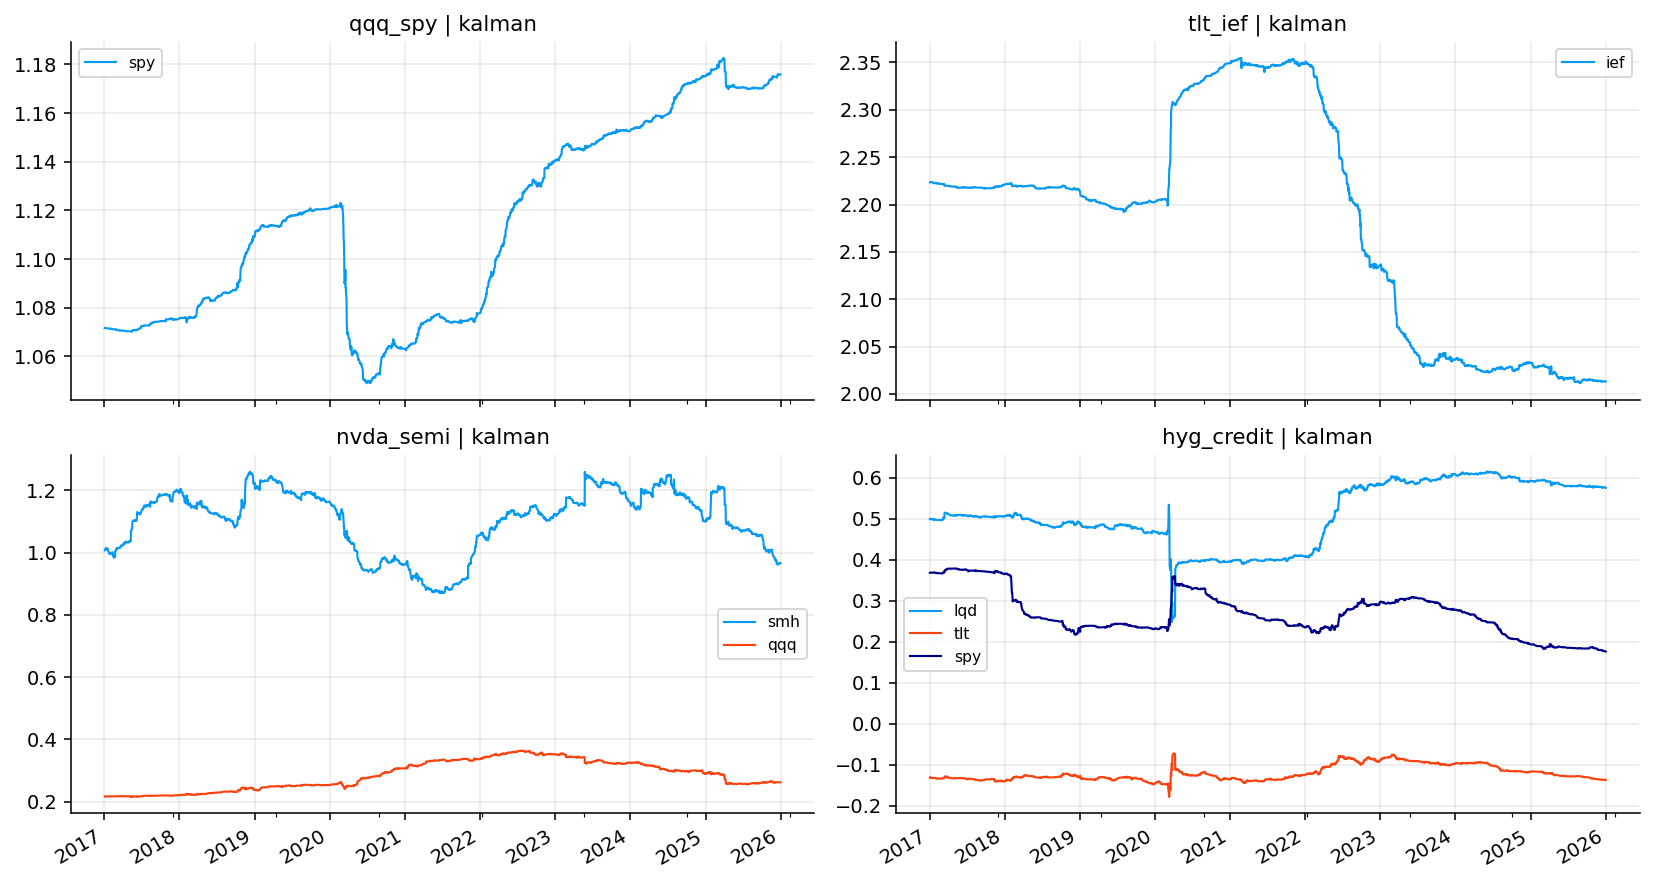

In [11]:
def kf_run(y, x, state0, pcov0, qdiag, obs_var):
    state = state0.copy()
    pcov = pcov0.copy()
    qcov = np.diag(qdiag)
    states, loglik = [], 0.0
    for yy, xx in zip(y, x):
        h = np.r_[1.0, xx]
        pcov = pcov + qcov
        pred = float(h @ state)
        s = float(h @ pcov @ h.T + obs_var)
        if s > 1e-12 and np.isfinite(s):
            err = float(yy - pred)
            loglik += -0.5 * (np.log(2 * np.pi * s) + err * err / s)
            k = (pcov @ h.T) / s
            state = state + k * err
            pcov = (np.eye(len(state)) - np.outer(k, h)) @ pcov
        states.append(state.copy())
    return np.asarray(states), loglik


def kf_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    if len(z) < n_train:
        return out

    train = z.iloc[:n_train]
    y_train = train[r.target].to_numpy(float)
    x_train = train[r.hedges].to_numpy(float)
    init_n = max(min(n_train // 4, 126), 30)
    a0, b0 = ols_fit(y_train[:init_n], x_train[:init_n])
    state0 = np.r_[a0, b0]
    resid = y_train - np.column_stack([np.ones(len(train)), x_train]) @ state0
    resid_var = max(np.nanvar(resid, ddof=1), 1e-8)
    pcov0 = np.eye(len(state0)) * max(resid_var, 1e-6)

    scale = np.r_[0.05, np.maximum(np.abs(b0), 0.25)]
    best_ll, best_q, best_r = -np.inf, np.r_[1e-7, np.repeat(1e-5, len(b0))], resid_var
    for q0 in [1e-7, 3e-7, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4]:
        qdiag = np.maximum(q0 * scale**2, 1e-12)
        for r0 in [0.5, 1.0, 2.0, 4.0]:
            obs_var = max(resid_var * r0, 1e-10)
            _, ll = kf_run(y_train, x_train, state0, pcov0, qdiag, obs_var)
            ll -= 0.5 * qdiag[1:].sum() / obs_var
            if ll > best_ll:
                best_ll, best_q, best_r = ll, qdiag, obs_var

    y_all = z[r.target].to_numpy(float)
    x_all = z[r.hedges].to_numpy(float)
    states, _ = kf_run(y_all, x_all, state0, pcov0, best_q, best_r)
    out.loc[z.index, r.hedges] = states[:, 1:]
    out.loc[z.index[:n_train - 1], r.hedges] = np.nan
    return out


books_kalman = {}
for r in rel_main:
    b0 = kf_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index)
    b2 = band_beta(b1, band=band)
    beta_daily[(r.name, "kalman")] = b0
    books_kalman[f"{r.name} | kalman"] = book_result(hedge_book(ret_b_main, r, b2))
    blog[f"{r.name} | kalman"] = {"rel": r.name, "model": "kalman", "desired": b0, "traded": b2}

bt_kalman = {**books_target, **books_kalman}
tab_kalman = model_table(bt_kalman, rel_main, ret_m_main)
display(tab_kalman[model_cols].round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, name in zip(axes.ravel(), ["qqq_spy", "tlt_ief", "nvda_semi", "hyg_credit"]):
    key = f"{name} | kalman"
    if key in blog:
        blog[key]["desired"].dropna(how="all").plot(ax=ax, lw=1.1)
        ax.set_title(key)
        ax.grid(True, alpha=0.25)
    else:
        ax.axis("off")
plt.tight_layout(); plt.show()

## 9. no-trade band sensitivity

,model,band,avg_vol_red,avg_es_red,avg_turnover_ann,avg_cost_drag_ann,avg_score
0,kalman,0.000,0.4498,0.4713,0.5337,0.0003,0.3299
1,ridge,0.000,0.4565,0.4809,1.8480,0.0009,0.5308
2,rolling,0.000,0.4563,0.4805,2.5419,0.0013,0.3280
3,kalman,0.025,0.4478,0.4695,0.3936,0.0002,0.3064
4,ridge,0.025,0.4560,0.4800,1.4773,0.0007,0.5632
5,rolling,0.025,0.4559,0.4799,2.1615,0.0011,0.3649
6,kalman,0.050,0.4456,0.4671,0.3517,0.0002,0.2501
7,ridge,0.050,0.4545,0.4790,1.2385,0.0006,0.5689
8,rolling,0.050,0.4556,0.4792,1.8604,0.0009,0.4337
9,kalman,0.075,0.4451,0.4671,0.3154,0.0002,0.2836


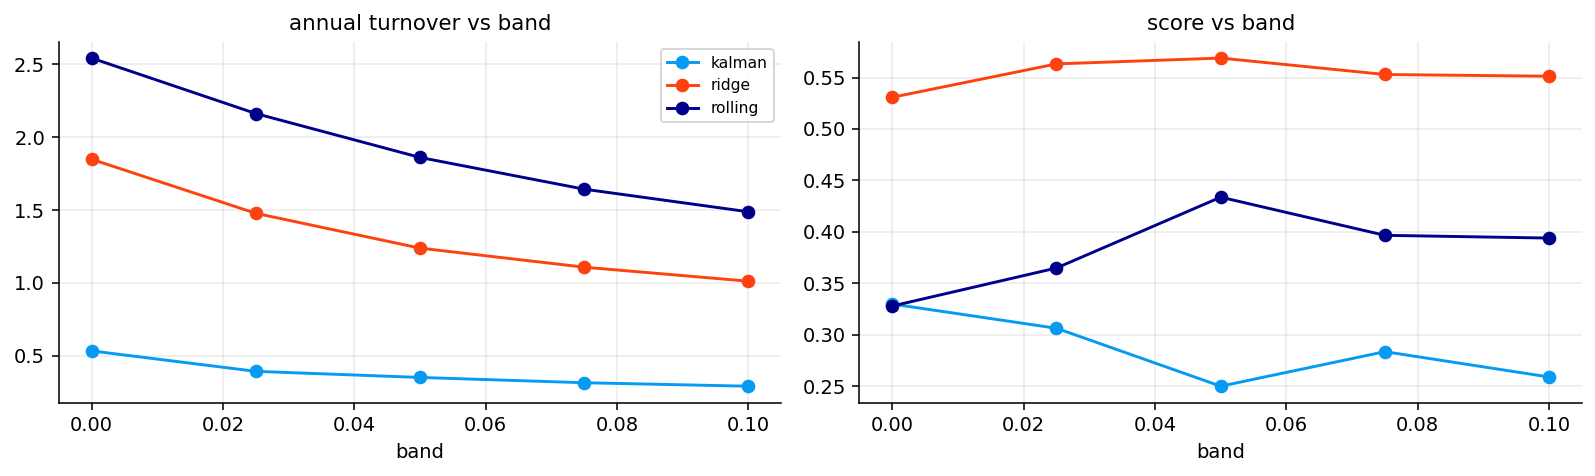

In [12]:
def band_norm(s, lower=False):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.notna().sum() <= 1:
        out = pd.Series(0.5, index=s.index)
    else:
        lo, hi = x.quantile(0.05), x.quantile(0.95)
        xc = x.clip(lo, hi)
        span = xc.max() - xc.min()
        out = pd.Series(0.5, index=s.index) if span <= 1e-12 else (xc - xc.min()) / span
    return (1 - out if lower else out).fillna(0.5)


def band_score(tab):
    parts = []
    for _, g in tab.groupby("relationship", sort=False):
        h = g.copy()
        vol_s = band_norm(h["vol_red"])
        dd_bad = (-pd.to_numeric(h["maxdd_diff"], errors="coerce")).clip(lower=0.0).div(0.10).clip(upper=1.0).fillna(0.0)
        vol_s = vol_s.mask(h["maxdd_diff"] < -0.05, np.minimum(vol_s, 0.50))
        h["score"] = (
            0.30 * vol_s
            + 0.20 * band_norm(h["es_red"])
            + 0.15 * band_norm(h["maxdd_diff"])
            + 0.15 * band_norm(h["beta_red"])
            + 0.10 * band_norm(h["beta_stability"])
            - 0.05 * (1 - band_norm(h["turnover_ann"], lower=True))
            - 0.05 * (1 - band_norm(h["cost_drag_ann"], lower=True))
            - 0.10 * dd_bad
        )
        parts.append(h)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


band_grid = [0.00, 0.025, 0.05, 0.075, 0.10]
dyn_models = ["rolling", "ridge", "kalman"]
sens_rows = []

for bnd in band_grid:
    books_sens = dict(books_target)
    for r in rel_main:
        for m in dyn_models:
            b1 = rebalance_beta(beta_daily[(r.name, m)], ret_b_main.index)
            b2 = band_beta(b1, band=bnd)
            books_sens[f"{r.name} | {m}"] = book_result(hedge_book(ret_b_main, r, b2))
    tab_sens = model_table(books_sens, rel_main, ret_m_main)
    for m, g in band_score(tab_sens).groupby("model"):
        sens_rows.append({
            "model": m,
            "band": bnd,
            "avg_vol_red": g["vol_red"].mean(),
            "avg_es_red": g["es_red"].mean(),
            "avg_turnover_ann": g["turnover_ann"].mean(),
            "avg_cost_drag_ann": g["cost_drag_ann"].mean(),
            "avg_score": g["score"].mean(),
        })

tab_band = pd.DataFrame(sens_rows)
display(tab_band.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.5), sharex=True)
for m, g in tab_band.groupby("model"):
    axes[0].plot(g["band"], g["avg_turnover_ann"], marker="o", label=m)
    axes[1].plot(g["band"], g["avg_score"], marker="o", label=m)
axes[0].set_title("annual turnover vs band")
axes[1].set_title("score vs band")
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("band")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. unified tournament

In [13]:
def norm_group(s, lower=False):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.notna().sum() == 0:
        out = pd.Series(0.5, index=s.index)
    else:
        xc = x.clip(x.quantile(0.05), x.quantile(0.95))
        span = xc.max() - xc.min()
        out = pd.Series(0.5, index=s.index) if span <= 1e-12 else (xc - xc.min()) / span
    return (1 - out if lower else out).fillna(0.5)


def score_table(tab):
    parts = []
    for _, g in tab.groupby("relationship", sort=False):
        h = g.copy()
        vol_s = norm_group(h["vol_red"])
        dd_bad = (-pd.to_numeric(h["maxdd_diff"], errors="coerce")).clip(lower=0.0).div(0.10).clip(upper=1.0).fillna(0.0)
        vol_s = vol_s.mask(h["maxdd_diff"] < -0.05, np.minimum(vol_s, 0.50))
        h["score"] = (
            0.30 * vol_s
            + 0.20 * norm_group(h["es_red"])
            + 0.15 * norm_group(h["maxdd_diff"])
            + 0.15 * norm_group(h["beta_red"])
            + 0.10 * norm_group(h["beta_stability"])
            - 0.05 * (1 - norm_group(h["turnover_ann"], lower=True))
            - 0.05 * (1 - norm_group(h["cost_drag_ann"], lower=True))
            - 0.10 * dd_bad
        )
        parts.append(h)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def best_table(tab):
    idx = tab.groupby("relationship")["score"].idxmax()
    cols = ["relationship", "model", "score", "vol_red", "es_red", "maxdd_diff", "cost_drag_ann"]
    return tab.loc[idx, cols].rename(columns={"model": "best_model"}).reset_index(drop=True)


def robust_table(tab):
    wins = best_table(tab)["best_model"].value_counts() if len(tab) else pd.Series(dtype=int)
    rows = []
    for m, g in tab.groupby("model"):
        rows.append({
            "model": m,
            "median_score": g["score"].median(),
            "median_vol_red": g["vol_red"].median(),
            "median_es_red": g["es_red"].median(),
            "median_cost_drag_ann": g["cost_drag_ann"].median(),
            "win_count": int(wins.get(m, 0)),
            "failure_count": int(((g["vol_red"] <= 0) | (g["score"] <= 0)).sum()),
        })
    return pd.DataFrame(rows).sort_values(["median_score", "win_count"], ascending=False)

,relationship,model,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann,beta_stability,rebalance_count
0,qqq_spy,static,0.6417,0.6509,0.1496,0.9547,0.1236,0.0001,1.0000,1
1,qqq_spy,rolling,0.6488,0.6592,0.1628,0.9773,0.2895,0.0001,0.9133,25
2,qqq_spy,ridge,0.6491,0.6586,0.1652,0.9835,0.2597,0.0001,0.9156,21
3,qqq_spy,kalman,0.6392,0.6480,0.1560,0.9537,0.1424,0.0001,0.9531,5
4,tlt_ief,static,0.5831,0.5382,0.2007,0.9156,0.2484,0.0001,1.0000,1
5,tlt_ief,rolling,0.6074,0.5836,0.2297,0.9963,0.6364,0.0003,0.7849,54
6,tlt_ief,ridge,0.6061,0.5833,0.2304,0.9658,0.6180,0.0003,0.7937,55
7,tlt_ief,kalman,0.5897,0.5486,0.2232,0.9348,0.2940,0.0001,0.8084,8
8,agg_bnd,static,0.7130,0.8054,0.1456,0.9838,0.1061,0.0001,1.0000,1
9,agg_bnd,rolling,0.6987,0.8015,0.1379,0.9980,0.1718,0.0001,0.9477,7


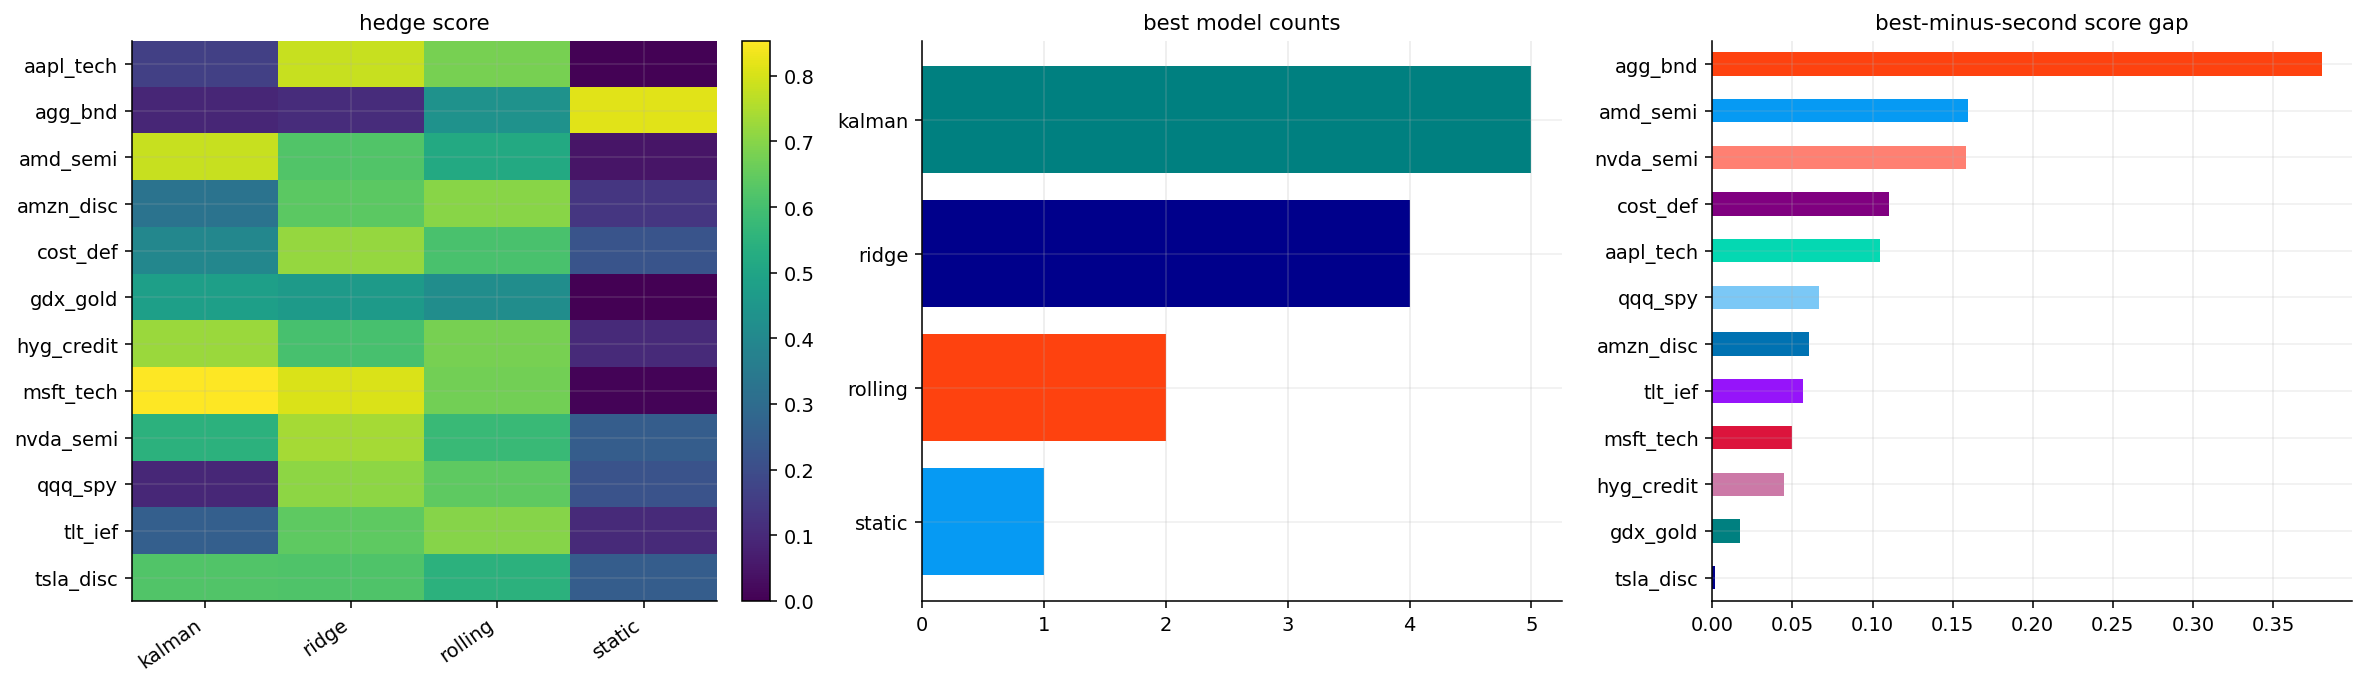

,relationship,best_model,score,vol_red,es_red,maxdd_diff,cost_drag_ann
0,aapl_tech,ridge,0.7828,0.4397,0.4676,0.0575,0.0006
1,agg_bnd,static,0.8161,0.7130,0.8054,0.1456,0.0001
2,amd_semi,kalman,0.7801,0.2970,0.3185,-0.0112,0.0002
3,amzn_disc,rolling,0.7000,0.4059,0.4538,0.1401,0.0009
4,cost_def,ridge,0.7187,0.2857,0.2854,0.0843,0.0004
5,gdx_gold,kalman,0.4807,0.3685,0.3884,-0.2578,0.0006
6,hyg_credit,kalman,0.7238,0.4843,0.5187,0.0480,0.0001
7,msft_tech,kalman,0.8533,0.5283,0.5442,0.1731,0.0002
8,nvda_semi,ridge,0.7379,0.4613,0.4859,0.1700,0.0008
9,qqq_spy,ridge,0.7087,0.6491,0.6586,0.1652,0.0001


,model,median_score,median_vol_red,median_es_red,median_cost_drag_ann,win_count,failure_count
1,ridge,0.6399,0.4505,0.4767,0.0005,4,0
2,rolling,0.6252,0.4513,0.4753,0.0008,2,0
0,kalman,0.4382,0.4293,0.4576,0.0001,5,0
3,static,0.1168,0.4081,0.4394,0.0001,1,1


,relationship,best_vol_red,median_vol_red,best_es_red,best_maxdd_diff,median_cost_drag_ann
0,aapl_tech,0.4416,0.4213,0.4681,0.0575,0.0004
1,agg_bnd,0.7130,0.6938,0.8054,0.1456,0.0001
2,amd_semi,0.2970,0.2948,0.3219,0.0050,0.0007
3,amzn_disc,0.4059,0.3955,0.4538,0.1401,0.0004
4,cost_def,0.2857,0.2813,0.2854,0.0843,0.0002
5,gdx_gold,0.3689,0.3679,0.3923,-0.2578,0.0006
6,hyg_credit,0.4937,0.4853,0.5226,0.0685,0.0002
7,msft_tech,0.5283,0.5264,0.5473,0.1770,0.0002
8,nvda_semi,0.4613,0.4584,0.4859,0.1705,0.0005
9,qqq_spy,0.6491,0.6452,0.6592,0.1652,0.0001


In [14]:
books_all = {}
books_all.update(books_target)
books_all.update(books_static)
books_all.update(books_roll)
books_all.update(books_ridge)
books_all.update(books_kalman)

bt_all = books_all
tab_model = model_table(bt_all, rel_main, ret_m_main)
tab_score = score_table(tab_model)
tab_best = best_table(tab_score)
tab_robust = robust_table(tab_score)

score_cols = ["relationship", "model", "vol_red", "es_red", "maxdd_diff", "beta_red", "turnover_ann", "cost_drag_ann", "beta_stability", "rebalance_count"]
display(tab_score[score_cols].round(4).head(20))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
score_mat = tab_score.pivot(index="relationship", columns="model", values="score")
im = axes[0].imshow(score_mat, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(score_mat.shape[1]), score_mat.columns, rotation=35, ha="right")
axes[0].set_yticks(range(score_mat.shape[0]), score_mat.index)
axes[0].set_title("hedge score")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

counts = tab_best["best_model"].value_counts().sort_values()
axes[1].barh(counts.index, counts.values, color=[colors[i % len(colors)] for i in range(len(counts))])
axes[1].set_title("best model counts")
axes[1].grid(True, axis="x", alpha=0.25)

gaps = {}
for name, g in tab_score.groupby("relationship"):
    vals = g["score"].sort_values(ascending=False).values
    gaps[name] = vals[0] - vals[1] if len(vals) > 1 else np.nan
pd.Series(gaps).sort_values().plot(kind="barh", ax=axes[2], color=[colors[(i + 2) % len(colors)] for i in range(len(gaps))])
axes[2].set_title("best-minus-second score gap")
axes[2].grid(True, axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

tab_quality = tab_model.groupby("relationship").agg(best_vol_red=("vol_red", "max"), median_vol_red=("vol_red", "median"), best_es_red=("es_red", "max"), best_maxdd_diff=("maxdd_diff", "max"), median_cost_drag_ann=("cost_drag_ann", "median")).reset_index()
display(tab_best.round(4))
display(tab_robust.round(4))
display(tab_quality.round(4))

## 11. residual gate

Residual trading is a second use of hedge ratios. A hedge can reduce risk without producing a tradable mean-reverting spread.

In [15]:
def statsmodels_tools():
    from statsmodels.tsa.stattools import adfuller, coint
    return adfuller, coint


def price_ols_beta(px, target, hedge):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0]).dropna()
    out = pd.DataFrame(np.nan, index=px.index, columns=["alpha", "beta"])
    if len(lp) < n_train:
        return out
    a, b = ols_fit(lp[target].iloc[:n_train], lp[[hedge]].iloc[:n_train])
    out.loc[lp.index[n_train - 1]:, ["alpha", "beta"]] = [a, b[0]]
    return out


def roll_price_beta(px, target, hedge):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0]).dropna()
    out = pd.DataFrame(np.nan, index=px.index, columns=["alpha", "beta"])
    for i in range(max(win, n_train) - 1, len(lp)):
        sample = lp.iloc[i - win + 1:i + 1]
        a, b = ols_fit(sample[target], sample[[hedge]])
        out.loc[lp.index[i], ["alpha", "beta"]] = [a, b[0]]
    return out


def kf_price_beta(px, target, hedge):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0]).dropna()
    out = pd.DataFrame(np.nan, index=px.index, columns=["alpha", "beta"])
    if len(lp) < n_train:
        return out
    a, b = ols_fit(lp[target].iloc[:n_train], lp[[hedge]].iloc[:n_train])
    state = np.array([a, b[0]], dtype=float)
    h0 = np.column_stack([np.ones(n_train), lp[hedge].iloc[:n_train].to_numpy(float)])
    resid = lp[target].iloc[:n_train].to_numpy(float) - h0 @ state
    obs_var = max(np.nanvar(resid, ddof=1), 1e-8)
    pcov = np.eye(2) * 0.10
    qcov = np.diag([1e-7, 1e-5])
    out.loc[lp.index[n_train - 1], ["alpha", "beta"]] = state
    for i in range(n_train, len(lp)):
        h = np.array([1.0, lp[hedge].iloc[i]])
        pcov = pcov + qcov
        s = float(h @ pcov @ h.T + obs_var)
        if s > 1e-12:
            k = (pcov @ h.T) / s
            state = state + k * (lp[target].iloc[i] - h @ state)
            pcov = (np.eye(2) - np.outer(k, h)) @ pcov
        out.loc[lp.index[i], ["alpha", "beta"]] = state
    return out


def log_spread(px, target, hedge, beta):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0])
    b = beta.reindex(lp.index).ffill()
    return (lp[target] - b["alpha"] - b["beta"] * lp[hedge]).replace([np.inf, -np.inf], np.nan)


def eg_test(y, x):
    _, coint = statsmodels_tools()
    z = pd.concat([y, x], axis=1).dropna()
    return float(coint(z.iloc[:, 0], z.iloc[:, 1])[1]) if len(z) >= 30 else np.nan


def adf_test(s):
    adfuller, _ = statsmodels_tools()
    x = pd.Series(s).dropna()
    try:
        return float(adfuller(x, autolag="AIC")[1]) if len(x) >= 30 else np.nan
    except Exception:
        return np.nan


def half_life(s):
    x = pd.Series(s).dropna()
    z = pd.concat([x.diff(), x.shift(1)], axis=1).dropna()
    if len(z) < 30:
        return np.nan
    _, b = ols_fit(z.iloc[:, 0], z.iloc[:, [1]])
    return -np.log(2) / b[0] if b[0] < 0 else np.inf


In [16]:
def z_signal(spread):
    z = (spread - spread.rolling(z_win).mean()) / spread.rolling(z_win).std()
    pos, cool, state = 0.0, 0, []
    for val in z:
        if not np.isfinite(val):
            state.append(pos)
        elif abs(val) > z_stop:
            pos = 0.0
            cool = z_cool
            state.append(pos)
        elif cool > 0:
            pos = 0.0
            cool -= 1
            state.append(pos)
        elif pos == 0 and val > z_in:
            pos = -1.0
            state.append(pos)
        elif pos == 0 and val < -z_in:
            pos = 1.0
            state.append(pos)
        elif abs(val) < z_out:
            pos = 0.0
            state.append(pos)
        else:
            state.append(pos)
    return pd.DataFrame({"z": z, "signal": pd.Series(state, index=z.index).shift(1).fillna(0.0)})


def spread_book(ret, target, hedge, beta, signal, cost_bps=cost_bps):
    panel = ret[[target, hedge]].dropna()
    b = beta["beta"].reindex(panel.index).ffill().shift(1)
    sig = signal.reindex(panel.index).fillna(0.0)
    data = pd.concat([panel, b.rename("beta"), sig.rename("signal")], axis=1).dropna()
    spread_ret = data[target] - data["beta"] * data[hedge]
    gross = data["signal"] * spread_ret
    weights = pd.DataFrame({target: data["signal"], hedge: -data["signal"] * data["beta"]})
    turnover = weights.diff().abs().sum(axis=1)
    if len(turnover):
        turnover.iloc[0] = weights.iloc[0].abs().sum()
    cost = turnover * cost_bps / 10000.0
    net = gross - cost
    return {
        "target_return": spread_ret,
        "gross_return": gross,
        "net_return": net,
        "turnover": turnover,
        "cost": cost,
        "beta": beta[["beta"]].rename(columns={"beta": hedge}).reindex(data.index).ffill(),
        "gross_values": (1 + gross).cumprod(),
        "net_values": (1 + net).cumprod(),
        "target_values": (1 + spread_ret).cumprod(),
    }

In [17]:
pairs = [
    ("agg_bnd", "agg", "bnd"),
    ("gdx_gld", "gdx", "gld"),
    ("tlt_ief", "tlt", "ief"),
    ("hyg_lqd", "hyg", "lqd"),
    ("xlk_qqq", "xlk", "qqq"),
    ("qqq_spy", "qqq", "spy"),
]
pairs = [p for p in pairs if p[1] in px.columns and p[2] in px.columns]
source_fns = {
    "static_log_ols": lambda t, h: price_ols_beta(px, t, h),
    "rolling_log_ols": lambda t, h: roll_price_beta(px, t, h),
    "kalman_log": lambda t, h: kf_price_beta(px, t, h),
}

gate_rows, resid_bt, resid_z, resid_meta = [], {}, {}, {}
for pair_name, target, hedge in pairs:
    lp = np.log(px[[target, hedge]].dropna())
    eg_p = eg_test(lp[target], lp[hedge])
    for beta_source, fn in source_fns.items():
        params = fn(target, hedge)
        spread = log_spread(px, target, hedge, params)
        sig = z_signal(spread)
        key = f"{pair_name} | {beta_source}"
        res = book_result(spread_book(ret_b, target, hedge, params, sig["signal"]))
        sdrop = spread.dropna()
        split = max(len(sdrop) // 2, 30)
        first, second = sdrop.iloc[:split], sdrop.iloc[split:]
        trades = int((sig["signal"].ne(0) & sig["signal"].shift(1).fillna(0).eq(0)).sum())
        cost_drag = max(total_return(res.gross_values) - total_return(res.net_values), 0.0)
        beta_turnover = params["beta"].dropna().diff().abs().mean()
        gate_rows.append({
            "pair": pair_name,
            "beta_source": beta_source,
            "eg_p": eg_p,
            "adf_p": adf_test(spread),
            "half_life": half_life(spread),
            "spread_vol": spread.diff().std() * np.sqrt(ann),
            "trades": trades,
            "cost_drag": cost_drag,
            "cost_drag_ann": res.cost.mean() * ann if len(res.cost) else 0.0,
            "break_p": max(adf_test(first), adf_test(second)) if len(second) >= 30 else np.nan,
            "beta_turnover": beta_turnover,
            "key": key,
        })
        resid_bt[key], resid_z[key] = res, sig
        resid_meta[key] = {"pair": pair_name, "beta_source": beta_source}

tab_gate = pd.DataFrame(gate_rows)
static_ok = tab_gate["beta_source"].str.contains("static")
tab_gate["eligible"] = (
    ((~static_ok) | (tab_gate["eg_p"] <= 0.10))
    & (tab_gate["adf_p"] <= 0.10)
    & (tab_gate["half_life"].between(2, 63))
    & (tab_gate["spread_vol"] >= 0.005)
    & (tab_gate["trades"] >= 3)
    & (tab_gate["cost_drag_ann"] <= 0.10)
    & (tab_gate["break_p"].fillna(1.0) <= 0.20)
    & (tab_gate["beta_turnover"].fillna(0.0) <= 0.25)
)
display(tab_gate[["pair", "beta_source", "eg_p", "adf_p", "half_life", "spread_vol", "trades", "cost_drag_ann", "beta_turnover", "eligible"]].round(4))

,pair,beta_source,eg_p,adf_p,half_life,spread_vol,trades,cost_drag_ann,beta_turnover,eligible
0,agg_bnd,static_log_ols,0.8258,0.5066,18.3256,0.0160,39,0.0086,0.0000,False
1,agg_bnd,rolling_log_ols,0.8258,0.0064,2.5249,0.0160,46,0.0101,0.0005,True
2,agg_bnd,kalman_log,0.8258,0.0000,0.6734,0.0001,68,0.0148,0.0001,False
3,gdx_gld,static_log_ols,0.1076,0.9985,inf,0.3423,22,0.0109,0.0000,False
4,gdx_gld,rolling_log_ols,0.1076,0.0000,18.7606,0.2400,28,0.0086,0.0074,True
5,gdx_gld,kalman_log,0.1076,0.0000,2.5041,0.2760,42,0.0199,0.0008,True
6,tlt_ief,static_log_ols,1.0000,0.9978,inf,0.0625,25,0.0081,0.0000,False
7,tlt_ief,rolling_log_ols,1.0000,0.0027,38.0215,0.0664,25,0.0080,0.0058,True
8,tlt_ief,kalman_log,1.0000,0.0000,1.2121,0.0357,67,0.0221,0.0004,False
9,hyg_lqd,static_log_ols,0.9448,0.9611,597.1985,0.0714,28,0.0054,0.0000,False


## 12. residual trading backtest

,pair,beta_source,trades,avg_hold,net_return,ann_vol,sharpe,maxdd,cost_drag,cost_drag_ann
1,agg_bnd,rolling_log_ols,46,15.4348,-0.0562,0.0052,-1.2293,-0.0562,0.0899,0.0101
4,gdx_gld,rolling_log_ols,28,25.1429,0.8787,0.1181,0.6535,-0.1395,0.1518,0.0086
7,tlt_ief,rolling_log_ols,25,33.7600,-0.0757,0.0468,-0.1642,-0.1932,0.0692,0.0080
10,hyg_lqd,rolling_log_ols,28,27.7143,0.0537,0.0405,0.1640,-0.0681,0.0497,0.0051
13,xlk_qqq,rolling_log_ols,30,24.6000,0.0582,0.0336,0.2045,-0.0893,0.0677,0.0069


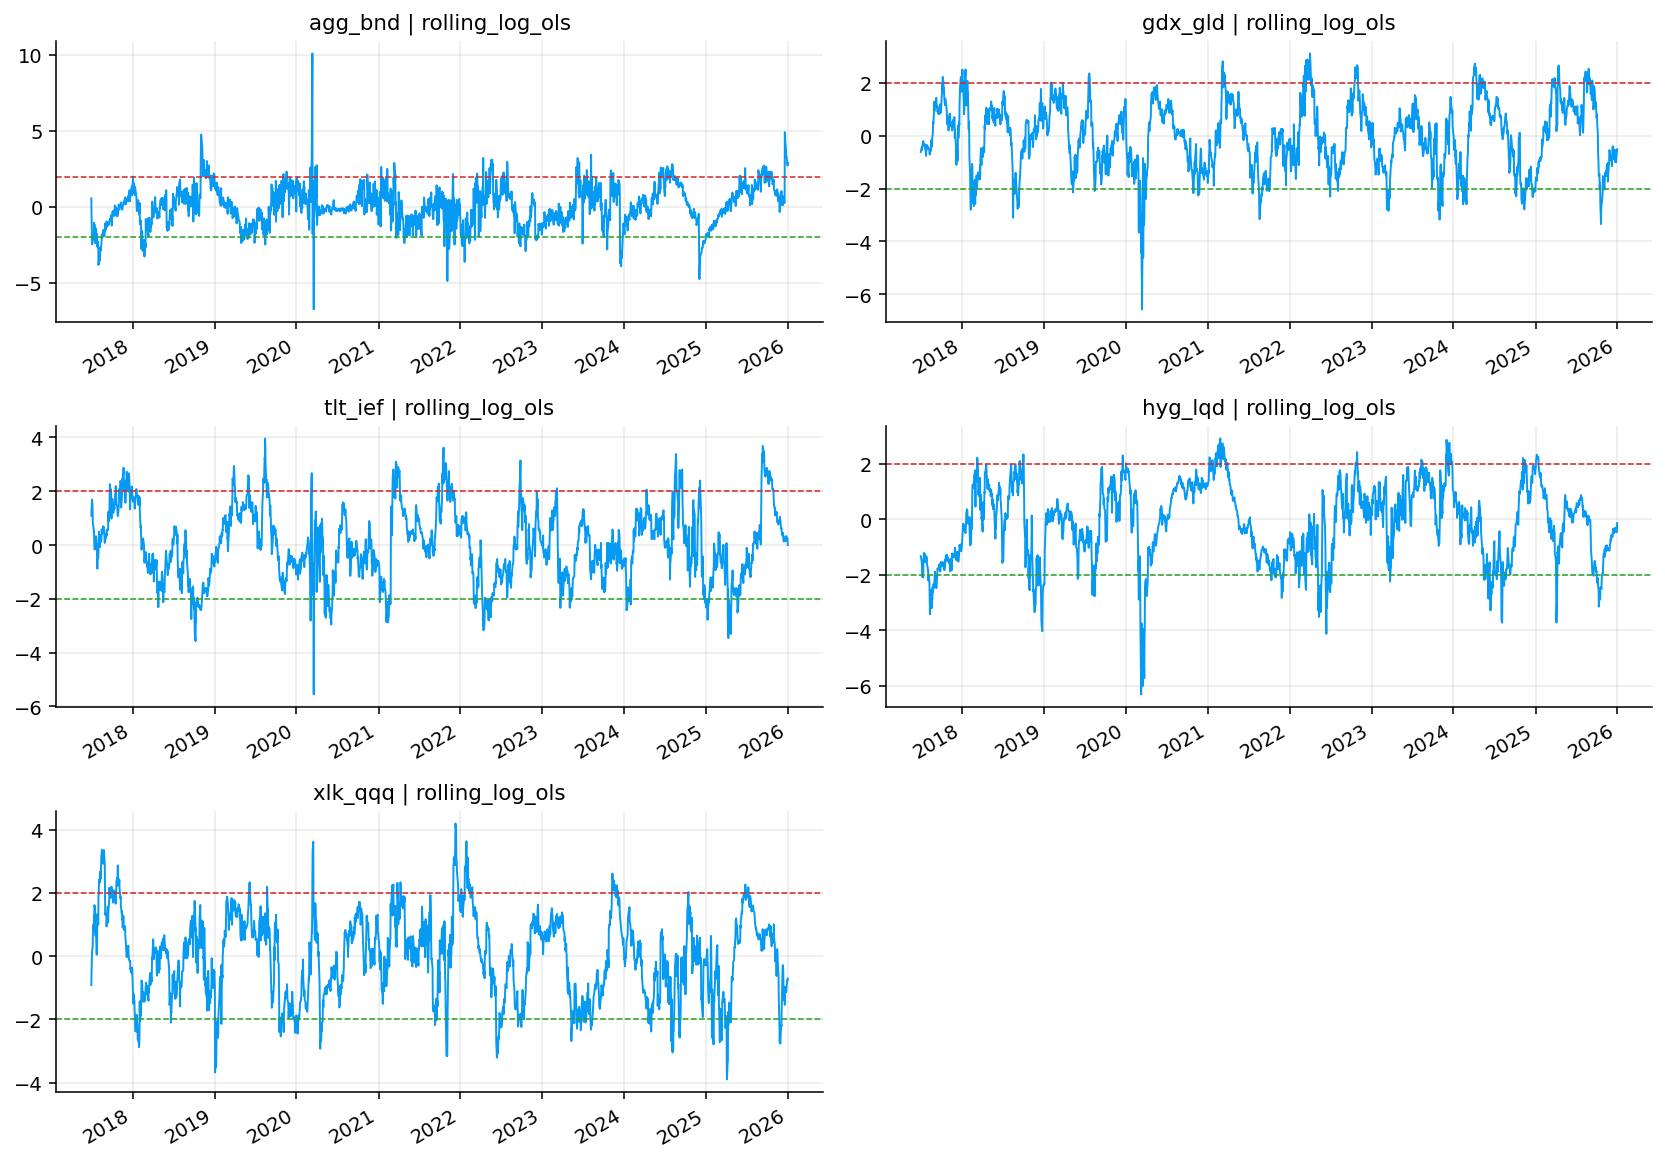

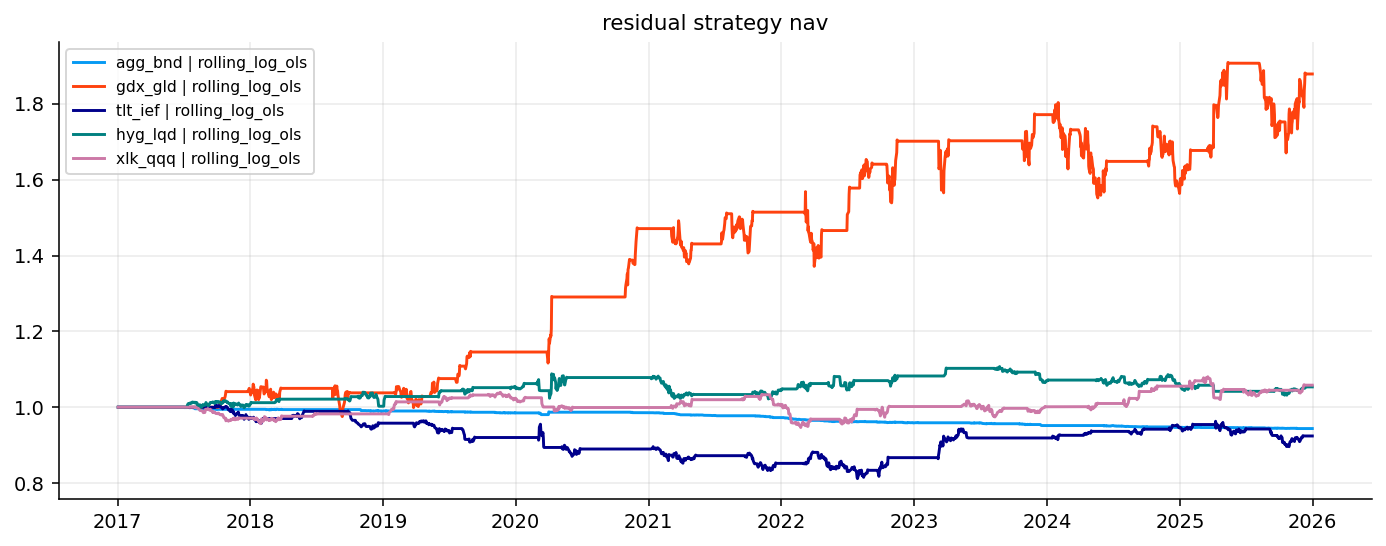

In [18]:
def avg_hold_days(sig):
    active = pd.Series(sig).fillna(0).ne(0)
    runs, n = [], 0
    for on in active:
        if on:
            n += 1
        elif n:
            runs.append(n)
            n = 0
    if n:
        runs.append(n)
    return float(np.mean(runs)) if runs else 0.0


resid_rows = []
for key, res in resid_bt.items():
    ret = res.net_returns.dropna()
    sig = resid_z[key]["signal"]
    vol = ret.std() * np.sqrt(ann)
    resid_rows.append({
        "pair": resid_meta[key]["pair"],
        "beta_source": resid_meta[key]["beta_source"],
        "trades": int((sig.ne(0) & sig.shift(1).fillna(0).eq(0)).sum()),
        "avg_hold": avg_hold_days(sig),
        "net_return": total_return(res.net_values),
        "ann_vol": vol,
        "sharpe": ret.mean() / ret.std() * np.sqrt(ann) if ret.std() > 1e-12 else np.nan,
        "maxdd": maxdd(ret),
        "cost_drag": max(total_return(res.gross_values) - total_return(res.net_values), 0.0),
        "cost_drag_ann": res.cost.mean() * ann if len(res.cost) else 0.0,
        "key": key,
    })

tab_resid = pd.DataFrame(resid_rows)
pick_gate = tab_gate[tab_gate["eligible"] & ~tab_gate["beta_source"].eq("kalman_log")]
rolling_keys = pick_gate.loc[pick_gate["beta_source"].eq("rolling_log_ols"), "key"].tolist()
keep_keys = rolling_keys or pick_gate["key"].tolist()
if not keep_keys:
    keep_keys = tab_resid[~tab_resid["beta_source"].eq("kalman_log")].sort_values("trades", ascending=False)["key"].head(6).tolist()

display(tab_resid[tab_resid["key"].isin(keep_keys)].drop(columns="key").round(4))

fig, axes = plt.subplots(math.ceil(len(keep_keys[:6]) / 2), 2, figsize=(12, 2.8 * math.ceil(len(keep_keys[:6]) / 2)), squeeze=False)
for ax, key in zip(axes.ravel(), keep_keys[:6]):
    resid_z[key]["z"].dropna().plot(ax=ax, lw=1.0)
    ax.axhline(z_in, ls="--", lw=0.8, c="tab:red")
    ax.axhline(-z_in, ls="--", lw=0.8, c="tab:green")
    ax.set_title(key)
    ax.grid(True, alpha=0.25)
for ax in axes.ravel()[len(keep_keys[:6]):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for key in keep_keys[:6]:
    nav = resid_bt[key].net_values
    ax.plot(nav.index, nav / nav.iloc[0], label=key)
ax.set_title("residual strategy nav")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

## 13. final applied output

,relationship,best_model,score,vol_red,es_red,maxdd_diff,cost_drag_ann
0,aapl_tech,ridge,0.7828,0.4397,0.4676,0.0575,0.0006
1,agg_bnd,static,0.8161,0.7130,0.8054,0.1456,0.0001
2,amd_semi,kalman,0.7801,0.2970,0.3185,-0.0112,0.0002
3,amzn_disc,rolling,0.7000,0.4059,0.4538,0.1401,0.0009
4,cost_def,ridge,0.7187,0.2857,0.2854,0.0843,0.0004
5,gdx_gold,kalman,0.4807,0.3685,0.3884,-0.2578,0.0006
6,hyg_credit,kalman,0.7238,0.4843,0.5187,0.0480,0.0001
7,msft_tech,kalman,0.8533,0.5283,0.5442,0.1731,0.0002
8,nvda_semi,ridge,0.7379,0.4613,0.4859,0.1700,0.0008
9,qqq_spy,ridge,0.7087,0.6491,0.6586,0.1652,0.0001


,pair,beta_source,trades,avg_hold,net_return,ann_vol,sharpe,maxdd,cost_drag,cost_drag_ann
1,agg_bnd,rolling_log_ols,46,15.4348,-0.0562,0.0052,-1.2293,-0.0562,0.0899,0.0101
4,gdx_gld,rolling_log_ols,28,25.1429,0.8787,0.1181,0.6535,-0.1395,0.1518,0.0086
7,tlt_ief,rolling_log_ols,25,33.7600,-0.0757,0.0468,-0.1642,-0.1932,0.0692,0.0080
10,hyg_lqd,rolling_log_ols,28,27.7143,0.0537,0.0405,0.1640,-0.0681,0.0497,0.0051
13,xlk_qqq,rolling_log_ols,30,24.6000,0.0582,0.0336,0.2045,-0.0893,0.0677,0.0069


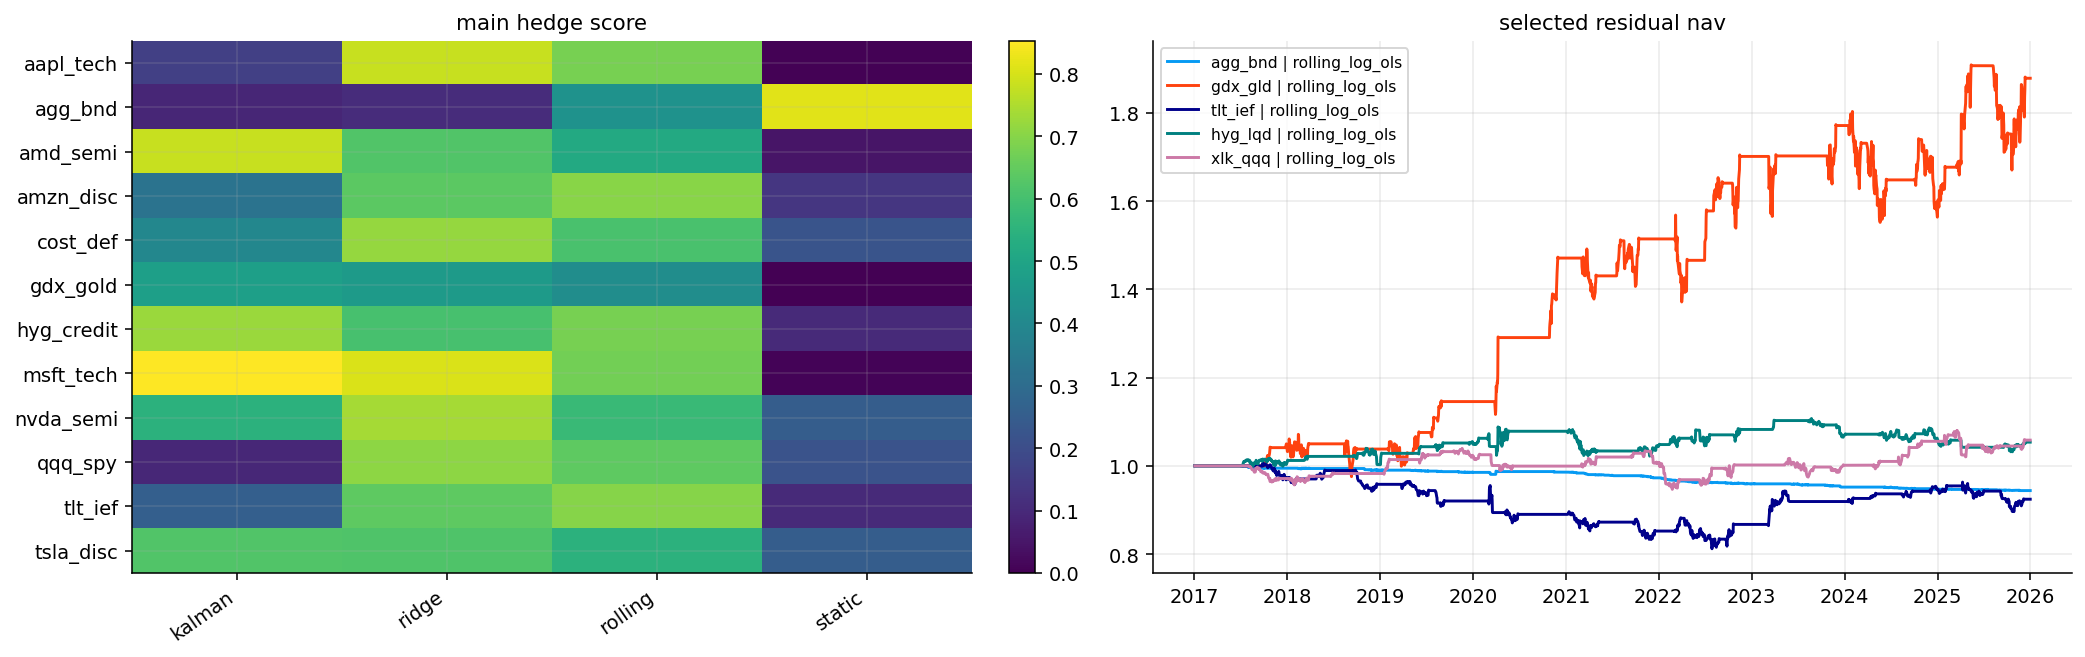

In [19]:
display(tab_best.round(4))
display(tab_resid[tab_resid["key"].isin(keep_keys)].drop(columns="key").round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
im = axes[0].imshow(score_mat, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(score_mat.shape[1]), score_mat.columns, rotation=35, ha="right")
axes[0].set_yticks(range(score_mat.shape[0]), score_mat.index)
axes[0].set_title("main hedge score")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
for key in keep_keys[:6]:
    nav = resid_bt[key].net_values
    axes[1].plot(nav.index, nav / nav.iloc[0], label=key)
axes[1].set_title("selected residual nav")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

Hedgeability and residual tradeability are different. Return hedges can reduce risk after costs even when the log-price residual is not a stable tradeable spread.

## 14. secondary implementation with extracted library

available secondary tickers: 30
missing secondary tickers: {}


,relationship,target,hedges,description,residual_pair,included
0,efa_hefa,efa,"hefa, uup",developed ex-us hedged by currency-hedged EAFE...,,True
1,ewj_dxj,ewj,"dxj, fxy, spy","japan hedged by currency-hedged japan, yen, an...",,True
2,ezu_hezu,ezu,"hezu, fxe, spy","eurozone hedged by currency-hedged eurozone, e...",,True
3,ewc_macro,ewc,"spy, xle, dbc, fxc","canada hedged by market, energy, commodities, ...",,True
4,ewa_macro,ewa,"efa, dbc, fxa","australia hedged by developed markets, commodi...",,True
5,ewh_macro,ewh,"fxi, mchi, vnq, uup","hong kong hedged by china, property, and dollar",,True
6,ewt_macro,ewt,"eem, smh, qqq, uup","taiwan hedged by emerging markets, semis, grow...",,True
7,ewy_macro,ewy,"eem, smh, ewt, uup","korea hedged by emerging markets, semis, taiwa...",,True
8,inda_macro,inda,"eem, qqq, uup","india hedged by emerging markets, growth, and ...",,True
9,ewz_macro,ewz,"eem, dbc, uup","brazil hedged by emerging markets, commodities...",,True


,relationship,target,hedges,description,start,end,obs,missing_pct,included
0,efa_hefa,efa,"hefa, uup",developed ex-us hedged by currency-hedged EAFE...,2015-01-02,2025-12-31,2766,0.0,True
1,ewj_dxj,ewj,"dxj, fxy, spy","japan hedged by currency-hedged japan, yen, an...",2015-01-02,2025-12-31,2766,0.0,True
2,ezu_hezu,ezu,"hezu, fxe, spy","eurozone hedged by currency-hedged eurozone, e...",2015-01-02,2025-12-31,2766,0.0,True
3,ewc_macro,ewc,"spy, xle, dbc, fxc","canada hedged by market, energy, commodities, ...",2015-01-02,2025-12-31,2766,0.0,True
4,ewa_macro,ewa,"efa, dbc, fxa","australia hedged by developed markets, commodi...",2015-01-02,2025-12-31,2766,0.0,True
5,ewh_macro,ewh,"fxi, mchi, vnq, uup","hong kong hedged by china, property, and dollar",2015-01-02,2025-12-31,2766,0.0,True
6,ewt_macro,ewt,"eem, smh, qqq, uup","taiwan hedged by emerging markets, semis, grow...",2015-01-02,2025-12-31,2766,0.0,True
7,ewy_macro,ewy,"eem, smh, ewt, uup","korea hedged by emerging markets, semis, taiwa...",2015-01-02,2025-12-31,2766,0.0,True
8,inda_macro,inda,"eem, qqq, uup","india hedged by emerging markets, growth, and ...",2015-01-02,2025-12-31,2766,0.0,True
9,ewz_macro,ewz,"eem, dbc, uup","brazil hedged by emerging markets, commodities...",2015-01-02,2025-12-31,2766,0.0,True


,relationship,target_vol,hedge_vol,corr,r2,beta_iqr,obs
0,efa_hefa,0.1730,0.0920,0.6964,0.4849,0.0588,2765
1,ewj_dxj,0.1743,0.1119,0.9253,0.8562,0.0380,2765
2,ezu_hezu,0.2056,0.1212,0.9524,0.9071,0.0152,2765
3,ewc_macro,0.1918,0.1483,0.8479,0.7190,0.0699,2765
4,ewa_macro,0.2308,0.1200,0.8128,0.6606,0.1231,2765
5,ewh_macro,0.1983,0.1618,0.8140,0.6625,0.1575,2765
6,ewt_macro,0.2113,0.1690,0.8065,0.6504,0.0919,2765
7,ewy_macro,0.2468,0.1647,0.8023,0.6437,0.1115,2765
8,inda_macro,0.2151,0.1301,0.6796,0.4618,0.1448,2765
9,ewz_macro,0.3537,0.1037,0.6446,0.4155,0.2010,2765


,relationship,best_model,score,vol_red,es_red,maxdd_diff,cost_drag_ann
0,efa_hefa,static,0.8057,0.8543,0.8717,0.2745,0.0001
1,ewa_macro,kalman,0.5651,0.5561,0.5659,0.2174,0.0002
2,ewc_macro,ridge,0.7109,0.5648,0.5636,0.2279,0.0004
3,ewh_macro,ridge,0.6132,0.4344,0.4368,-0.0001,0.0004
4,ewj_dxj,kalman,0.7336,0.7899,0.7939,0.0412,0.0001
5,ewt_macro,rolling,0.7000,0.5082,0.5353,0.2079,0.0006
6,eww_macro,kalman,0.6352,0.2886,0.3101,0.0280,0.0003
7,ewy_macro,kalman,0.7313,0.4957,0.5081,0.0647,0.0002
8,ewz_macro,ridge,0.6035,0.2770,0.2739,0.0255,0.0012
9,ezu_hezu,kalman,0.8573,0.9132,0.9137,0.2433,0.0001


,model,median_score,median_vol_red,median_es_red,median_cost_drag_ann,win_count,failure_count
0,rolling,0.5840,0.5334,0.5465,0.0005,2,0
1,kalman,0.5780,0.5269,0.5397,0.0001,6,0
2,ridge,0.5253,0.5337,0.5486,0.0004,3,2
3,static,0.2530,0.5048,0.5325,0.0001,1,0


,relationship,best_vol_red,median_vol_red,best_es_red,median_es_red,best_maxdd_diff,median_cost_drag_ann,median_turnover_ann,model_count
0,ezu_hezu,0.9132,0.9092,0.9137,0.9099,0.2592,0.0001,0.2628,4
1,efa_hefa,0.8552,0.8541,0.8722,0.8712,0.2797,0.0001,0.2811,4
2,fxi_macro,0.7983,0.7893,0.8023,0.7917,0.3446,0.0002,0.4449,4
3,ewj_dxj,0.7899,0.7857,0.7985,0.7905,0.0425,0.0002,0.3148,4
4,ewc_macro,0.5648,0.5559,0.5636,0.5583,0.2279,0.0002,0.4939,4
5,ewa_macro,0.5621,0.5581,0.5676,0.5660,0.2860,0.0003,0.6328,4
6,ewt_macro,0.5082,0.5039,0.5353,0.5283,0.2079,0.0003,0.6044,4
7,ewy_macro,0.4957,0.4927,0.5081,0.5041,0.1922,0.0004,0.8608,4
8,ewh_macro,0.4401,0.4224,0.4368,0.4287,0.1059,0.0003,0.6525,4
9,inda_macro,0.3294,0.3167,0.3193,0.3071,0.1680,0.0004,0.7361,4


,pair,beta_source,eg_p,adf_p,half_life,spread_vol,trades,cost_drag_ann,beta_turnover,eligible
0,efa_hefa,static_log_ols,0.2285,0.6914,466.7308,0.0685,20,0.0042,0.0000,False
1,efa_hefa,rolling_log_ols,0.2285,0.0028,54.4934,0.0759,26,0.0062,0.0046,True
2,efa_hefa,kalman_log,0.2285,0.0000,3.8359,0.0597,46,0.0096,0.0003,True
3,ewj_dxj,static_log_ols,0.3112,0.1142,138.5738,0.1215,22,0.0032,0.0000,False
4,ewj_dxj,rolling_log_ols,0.3112,0.0025,44.3013,0.1282,24,0.0049,0.0046,True
5,ewj_dxj,kalman_log,0.3112,0.0000,4.7397,0.0996,44,0.0069,0.0003,True
6,ezu_hezu,static_log_ols,0.3742,0.4043,218.5838,0.0825,21,0.0043,0.0000,False
7,ezu_hezu,rolling_log_ols,0.3742,0.0022,52.5013,0.0862,24,0.0057,0.0043,True
8,ezu_hezu,kalman_log,0.3742,0.0000,2.8434,0.0666,54,0.0111,0.0005,True
9,fxi_mchi,static_log_ols,0.5376,0.1176,242.2866,0.0661,19,0.0044,0.0000,False


,pair,beta_source,trades,net_return,ann_vol,sharpe,maxdd,cost_drag,cost_drag_ann
1,efa_hefa,rolling_log_ols,26,-0.0155,0.0441,-0.0174,-0.1160,0.0561,0.0062
4,ewj_dxj,rolling_log_ols,24,-0.0257,0.0833,0.0065,-0.2879,0.0438,0.0049
7,ezu_hezu,rolling_log_ols,24,0.0647,0.0489,0.1671,-0.1329,0.0557,0.0057
10,fxi_mchi,rolling_log_ols,30,0.1537,0.0469,0.3631,-0.1054,0.0654,0.0061
13,ewt_ewy,rolling_log_ols,25,-0.3628,0.1147,-0.3805,-0.4856,0.0280,0.0048


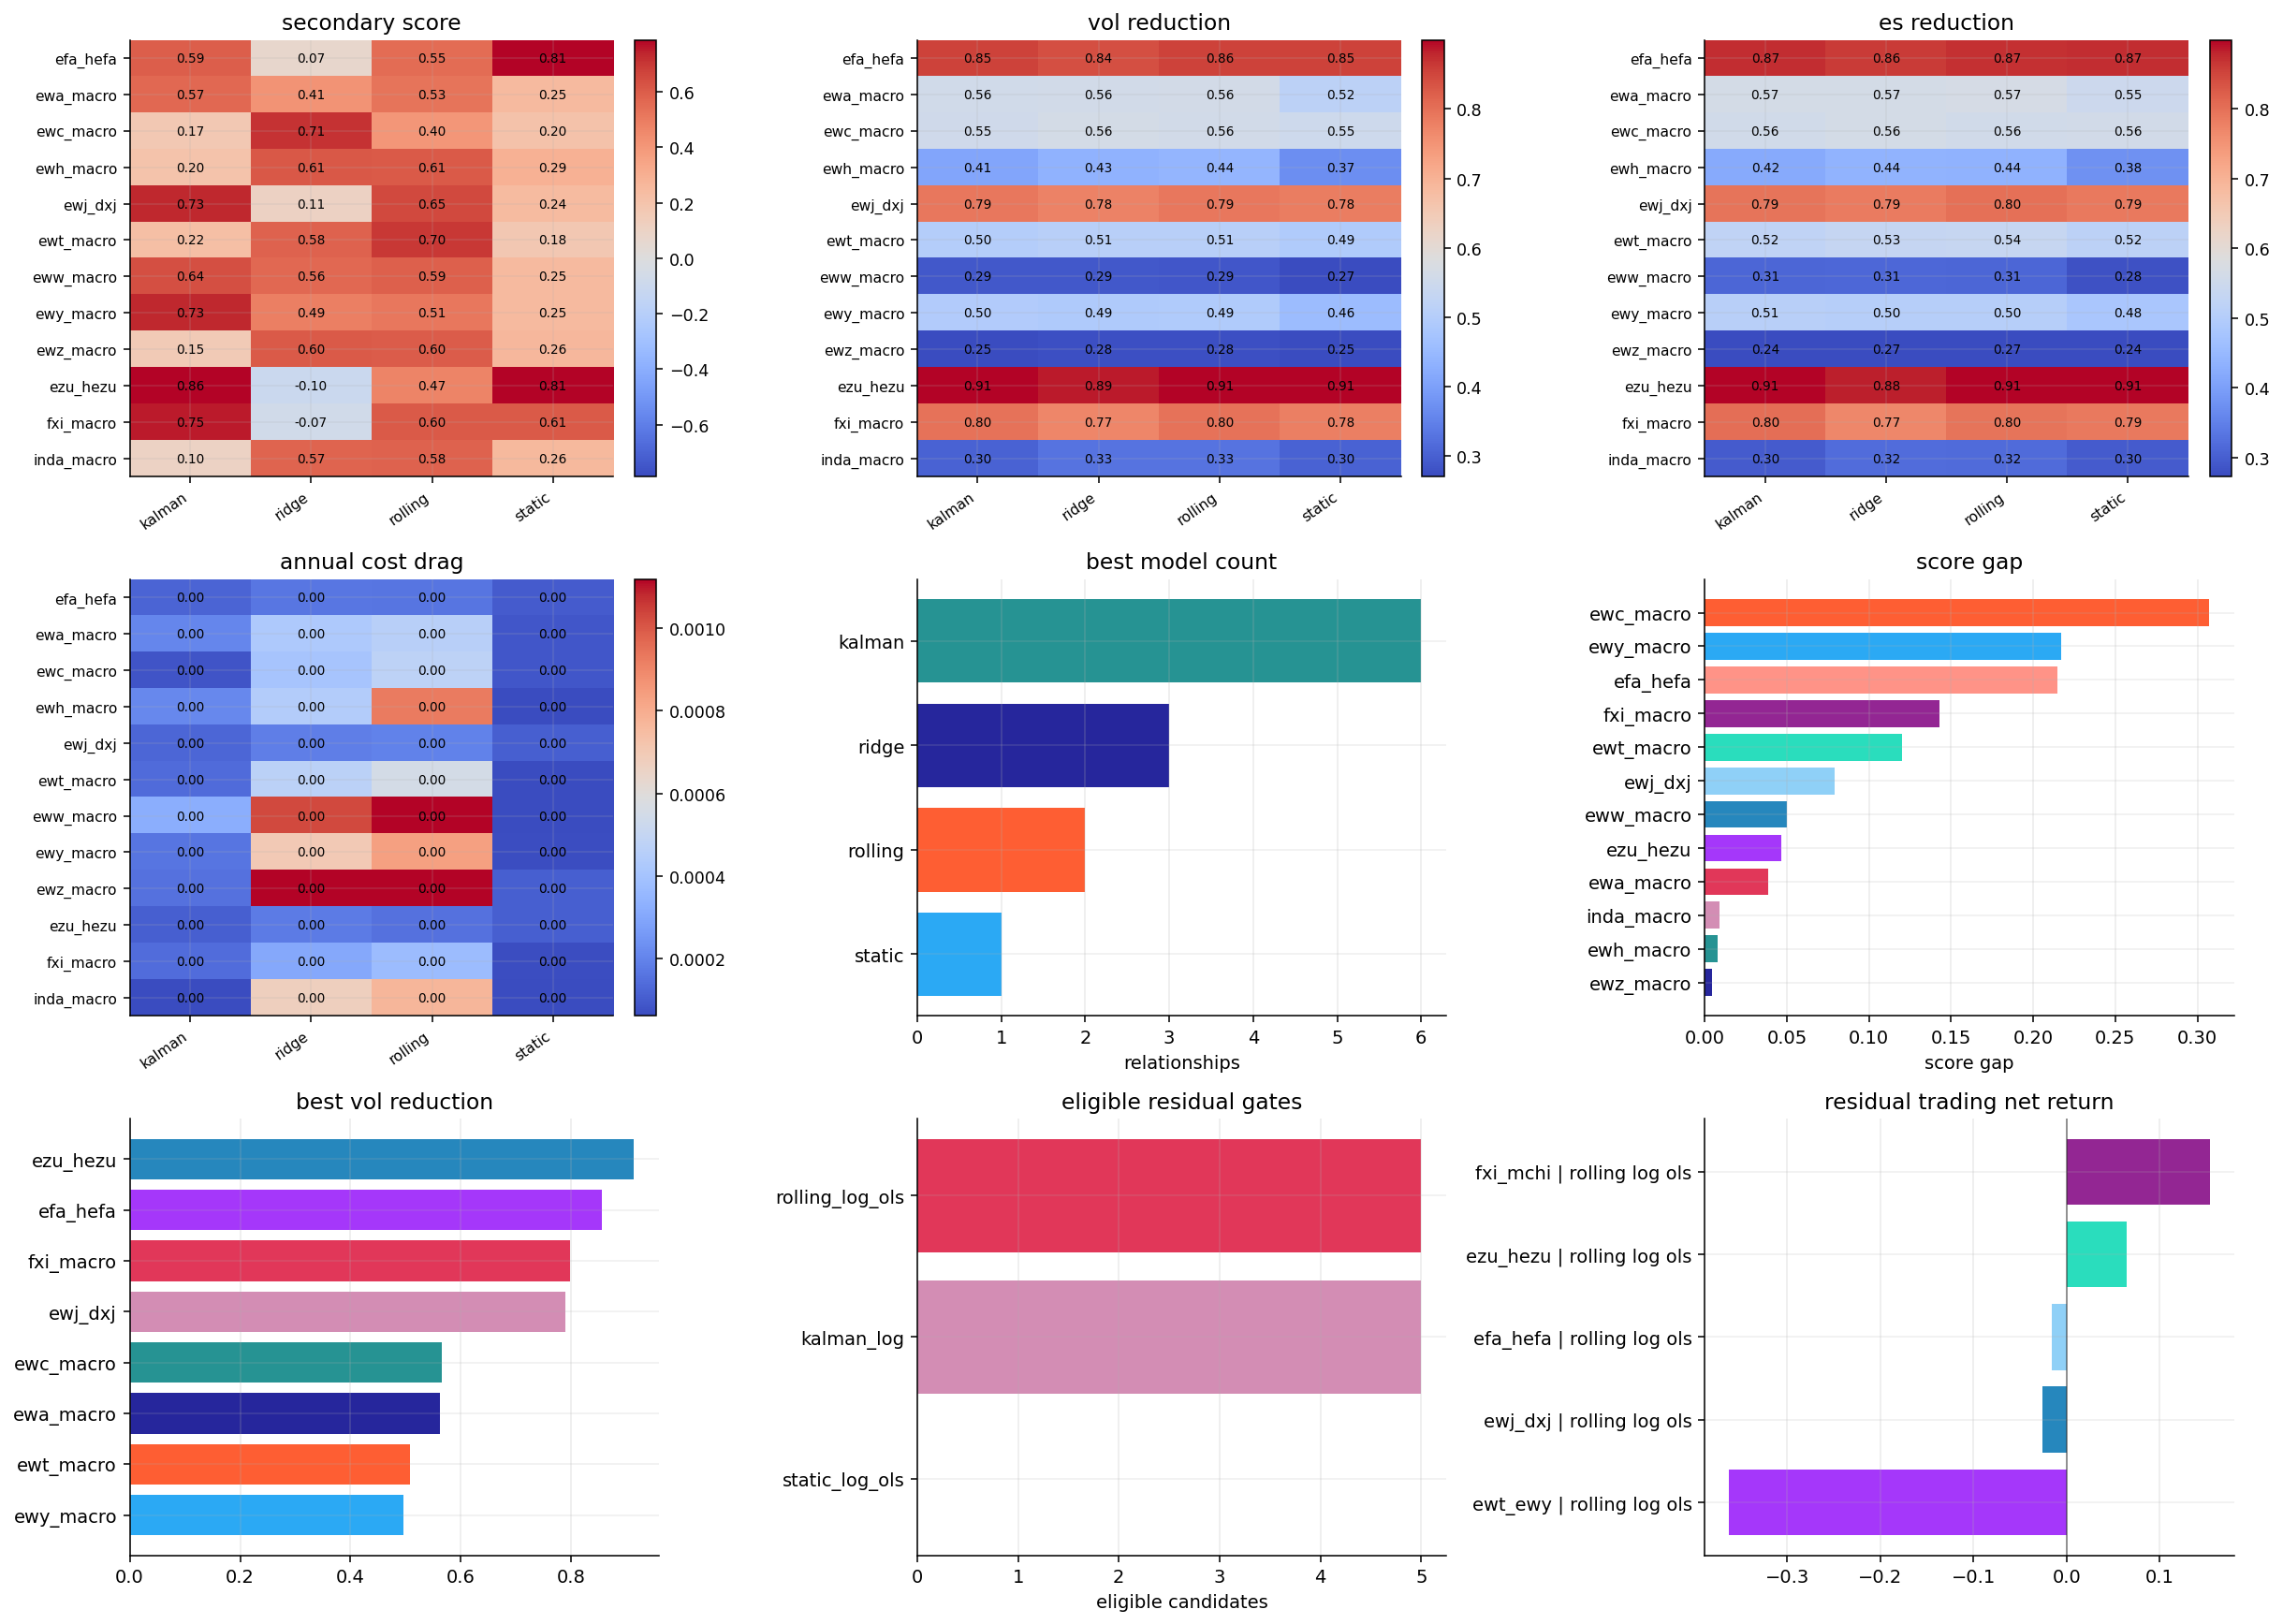

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display

from quantfinlab.risk import drawdown_series
from quantfinlab.backtest.hedging import run_many_hedge_backtests
from quantfinlab.portfolio.universe import prices_to_returns
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.hedging.relations import rel, rel_table, rel_tickers, filter_rels
from quantfinlab.hedging.ratios import ols_beta, roll_beta, ridge_beta, kf_beta
from quantfinlab.hedging.policies import rebalance_beta, band_beta
from quantfinlab.hedging.metrics import coverage_table, diag_table, model_table, score_table, best_table, robust_table, quality_table
from quantfinlab.hedging.residual import (
    price_ols_beta as lib_price_ols_beta,
    roll_price_beta as lib_roll_price_beta,
    kf_price_beta as lib_kf_price_beta,
    log_spread as lib_log_spread,
    eg_test as lib_eg_test,
    adf_test as lib_adf_test,
    half_life as lib_half_life,
    z_signal as lib_z_signal,
    resid_gate as lib_resid_gate,
)
from quantfinlab.plotting import hedging as hplot

start = "2015-01-01"
end = "2026-01-01"
ann = 252
n_train = 504
win = 252
alpha = 10.0
freq = "w-fri"
band = 0.05
cost_bps = 5.0
z_win = 126
z_in = 2.0
z_out = 0.5
z_stop = 3.5
z_cool = 5
colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)


def sec_zero_beta(index, r):
    return pd.DataFrame(0.0, index=pd.DatetimeIndex(index)[:1], columns=r.hedges)


def sec_total_return(nav):
    s = pd.Series(nav).dropna()
    return float(s.iloc[-1] / s.iloc[0] - 1) if len(s) > 1 and abs(s.iloc[0]) > 1e-12 else np.nan


def sec_maxdd(ret):
    s = pd.Series(ret).dropna()
    return float(drawdown_series(s, input_kind="returns").min()) if len(s) else np.nan


class sec_result:
    def __init__(self, d):
        self.__dict__.update(d)
        self.net_returns = d["net_return"]
        self.gross_returns = d["gross_return"]


def sec_spread_book(ret, target, hedge, beta, signal):
    panel = ret[[target, hedge]].dropna()
    b = beta["beta"].reindex(panel.index).ffill().shift(1)
    sig = signal.reindex(panel.index).fillna(0.0)
    data = pd.concat([panel, b.rename("beta"), sig.rename("signal")], axis=1).dropna()
    spread_ret = data[target] - data["beta"] * data[hedge]
    gross = data["signal"] * spread_ret
    weights = pd.DataFrame({target: data["signal"], hedge: -data["signal"] * data["beta"]})
    turnover = weights.diff().abs().sum(axis=1)
    if len(turnover):
        turnover.iloc[0] = weights.iloc[0].abs().sum()
    cost = turnover * cost_bps / 10000.0
    net = gross - cost
    return sec_result({
        "target_return": spread_ret,
        "gross_return": gross,
        "net_return": net,
        "turnover": turnover,
        "cost": cost,
        "beta": beta[["beta"]].rename(columns={"beta": hedge}).reindex(data.index).ffill(),
        "gross_values": (1 + gross).cumprod(),
        "net_values": (1 + net).cumprod(),
        "target_values": (1 + spread_ret).cumprod(),
    })


etf_path = Path("../data/ETF_data.csv")
nasdaq_path = Path("../data/nasdaq_all_close_volume.parquet")
etf_px_sec = load_yfinance_panel(etf_path, fields=("close",), start=start, end=end, lowercase=True)["close"]
stock_px_sec = load_yfinance_panel(nasdaq_path, fields=("close",), start=start, end=end, lowercase=True)["close"]

px_sec_all = pd.concat([stock_px_sec, etf_px_sec], axis=1)
px_sec_all = px_sec_all.loc[:, ~px_sec_all.columns.duplicated(keep="last")]
px_sec_all = px_sec_all.loc[(px_sec_all.index >= start) & (px_sec_all.index <= end)].sort_index()
ret_m_all = prices_to_returns(px_sec_all, kind="log")
ret_b_all = prices_to_returns(px_sec_all, kind="simple")

rel_sec = [
    rel("efa_hefa", "efa", ["hefa", "uup"], "developed ex-us hedged by currency-hedged EAFE and dollar"),
    rel("ewj_dxj", "ewj", ["dxj", "fxy", "spy"], "japan hedged by currency-hedged japan, yen, and market"),
    rel("ezu_hezu", "ezu", ["hezu", "fxe", "spy"], "eurozone hedged by currency-hedged eurozone, euro, and market"),
    rel("ewc_macro", "ewc", ["spy", "xle", "dbc", "fxc"], "canada hedged by market, energy, commodities, and cad"),
    rel("ewa_macro", "ewa", ["efa", "dbc", "fxa"], "australia hedged by developed markets, commodities, and aud"),
    rel("ewh_macro", "ewh", ["fxi", "mchi", "vnq", "uup"], "hong kong hedged by china, property, and dollar"),
    rel("ewt_macro", "ewt", ["eem", "smh", "qqq", "uup"], "taiwan hedged by emerging markets, semis, growth, and dollar"),
    rel("ewy_macro", "ewy", ["eem", "smh", "ewt", "uup"], "korea hedged by emerging markets, semis, taiwan, and dollar"),
    rel("inda_macro", "inda", ["eem", "qqq", "uup"], "india hedged by emerging markets, growth, and dollar"),
    rel("ewz_macro", "ewz", ["eem", "dbc", "uup"], "brazil hedged by emerging markets, commodities, and dollar"),
    rel("eww_macro", "eww", ["spy", "eem", "uup"], "mexico hedged by us market, emerging markets, and dollar"),
    rel("fxi_macro", "fxi", ["mchi", "kweb", "ashr", "uup"], "china large caps hedged by china etf sleeves and dollar"),
]

sec_view = rel_table(rel_sec, px_sec_all.columns)
rel_sec, missing_sec = filter_rels(rel_sec, px_sec_all.columns)
tickers_sec = rel_tickers(rel_sec)
print(f"available secondary tickers: {len(tickers_sec)}")
print("missing secondary tickers:", missing_sec)
display(sec_view)

px_sec = px_sec_all[tickers_sec]
ret_m_sec = ret_m_all[tickers_sec]
ret_b_sec = ret_b_all[tickers_sec]
display(coverage_table(px_sec, rel_sec).round(4))

betas, books_sec, blog_sec = {}, {}, {}
for r in rel_sec:
    betas[(r.name, "static")] = ols_beta(ret_m_sec, r, n_train=n_train)
    betas[(r.name, "rolling")] = roll_beta(ret_m_sec, r, win=win, n_train=n_train)
    betas[(r.name, "ridge")] = ridge_beta(ret_m_sec, r, win=win, alpha=alpha, n_train=n_train)
    betas[(r.name, "kalman")] = kf_beta(ret_m_sec, r, n_train=n_train)
    books_sec[f"{r.name} | target"] = {"target": r.target, "hedges": r.hedges, "beta": sec_zero_beta(ret_b_sec.index, r)}
    for m in ["static", "rolling", "ridge", "kalman"]:
        b1 = rebalance_beta(betas[(r.name, m)], ret_b_sec.index, freq=freq)
        b2 = b1.ffill() if m == "static" else band_beta(b1, band=band)
        books_sec[f"{r.name} | {m}"] = {"target": r.target, "hedges": r.hedges, "beta": b2}
        blog_sec[f"{r.name} | {m}"] = {"rel": r.name, "model": m, "desired": betas[(r.name, m)], "traded": b2}

bt_sec = run_many_hedge_backtests(books_sec, returns=ret_b_sec[tickers_sec], cost_bps=cost_bps)
tab_diag_sec = diag_table(ret_m_sec, rel_sec, beta_log=blog_sec, ann=ann)
tab_model_sec = model_table(bt_sec, rel_sec, ret_m_sec, ann=ann)
tab_score_sec = score_table(tab_model_sec)
tab_best_sec = best_table(tab_score_sec)
tab_robust_sec = robust_table(tab_score_sec)
tab_quality_sec = quality_table(tab_model_sec)

display(tab_diag_sec.round(4))
display(tab_best_sec.round(4))
display(tab_robust_sec.round(4))
display(tab_quality_sec.round(4))

pairs_sec = [
    ("efa_hefa", "efa", "hefa"),
    ("ewj_dxj", "ewj", "dxj"),
    ("ezu_hezu", "ezu", "hezu"),
    ("fxi_mchi", "fxi", "mchi"),
    ("ewt_ewy", "ewt", "ewy"),
]
pairs_sec = [p for p in pairs_sec if p[1] in px_sec_all.columns and p[2] in px_sec_all.columns]
source_fns_sec = {
    "static_log_ols": lambda t, h: lib_price_ols_beta(px_sec_all, t, h, n_train=n_train),
    "rolling_log_ols": lambda t, h: lib_roll_price_beta(px_sec_all, t, h, win=win, n_train=n_train),
    "kalman_log": lambda t, h: lib_kf_price_beta(px_sec_all, t, h, n_train=n_train),
}

gate_rows_sec, resid_sec, z_sec, meta_sec = [], {}, {}, {}
for pair_name, target, hedge in pairs_sec:
    lp = np.log(px_sec_all[[target, hedge]].dropna())
    eg_p = lib_eg_test(lp[target], lp[hedge])
    for beta_source, fn in source_fns_sec.items():
        params = fn(target, hedge)
        spread = lib_log_spread(px_sec_all, target, hedge, params)
        sig = lib_z_signal(spread, z_win=z_win, z_in=z_in, z_out=z_out, z_stop=z_stop, z_cool=z_cool)
        key = f"{pair_name} | {beta_source}"
        res = sec_spread_book(ret_b_all, target, hedge, params, sig["signal"])
        sdrop = spread.dropna()
        split = max(len(sdrop) // 2, 30)
        first, second = sdrop.iloc[:split], sdrop.iloc[split:]
        trades = int((sig["signal"].ne(0) & sig["signal"].shift(1).fillna(0).eq(0)).sum())
        gate_rows_sec.append({
            "pair": pair_name,
            "beta_source": beta_source,
            "eg_p": eg_p,
            "adf_p": lib_adf_test(spread),
            "half_life": lib_half_life(spread),
            "spread_vol": spread.diff().std() * np.sqrt(ann),
            "trades": trades,
            "cost_drag": max(sec_total_return(res.gross_values) - sec_total_return(res.net_values), 0.0),
            "cost_drag_ann": res.cost.mean() * ann if len(res.cost) else 0.0,
            "break_p": max(lib_adf_test(first), lib_adf_test(second)) if len(second) >= 30 else np.nan,
            "beta_turnover": params["beta"].dropna().diff().abs().mean(),
            "key": key,
        })
        resid_sec[key], z_sec[key], meta_sec[key] = res, sig, {"pair": pair_name, "beta_source": beta_source}

tab_gate_sec = lib_resid_gate(gate_rows_sec)
display(tab_gate_sec[["pair", "beta_source", "eg_p", "adf_p", "half_life", "spread_vol", "trades", "cost_drag_ann", "beta_turnover", "eligible"]].round(4))

resid_rows_sec = []
for key, res in resid_sec.items():
    ret = res.net_returns.dropna()
    sig = z_sec[key]["signal"]
    resid_rows_sec.append({
        "pair": meta_sec[key]["pair"],
        "beta_source": meta_sec[key]["beta_source"],
        "trades": int((sig.ne(0) & sig.shift(1).fillna(0).eq(0)).sum()),
        "net_return": sec_total_return(res.net_values),
        "ann_vol": ret.std() * np.sqrt(ann),
        "sharpe": ret.mean() / ret.std() * np.sqrt(ann) if ret.std() > 1e-12 else np.nan,
        "maxdd": sec_maxdd(ret),
        "cost_drag": max(sec_total_return(res.gross_values) - sec_total_return(res.net_values), 0.0),
        "cost_drag_ann": res.cost.mean() * ann if len(res.cost) else 0.0,
        "key": key,
    })

tab_resid_sec = pd.DataFrame(resid_rows_sec)
pick_sec = tab_gate_sec[tab_gate_sec["eligible"] & ~tab_gate_sec["beta_source"].eq("kalman_log")]
rolling_sec = pick_sec.loc[pick_sec["beta_source"].eq("rolling_log_ols"), "key"].tolist()
keep_sec = rolling_sec or pick_sec["key"].tolist()
if not keep_sec and not tab_resid_sec.empty:
    keep_sec = tab_resid_sec[~tab_resid_sec["beta_source"].eq("kalman_log")].sort_values("trades", ascending=False)["key"].head(5).tolist()
show_resid_sec = tab_resid_sec[tab_resid_sec["key"].isin(keep_sec)].copy()
display(show_resid_sec.drop(columns="key").round(4))

fig, ax = plt.subplots(3, 3, figsize=(17.5, 12.5))
ax = ax.ravel()
hplot.plot_score_heatmap(tab_score_sec, ax=ax[0], title="secondary score")
hplot.plot_metric_heatmap(tab_score_sec, "vol_red", ax=ax[1], title="vol reduction")
hplot.plot_metric_heatmap(tab_score_sec, "es_red", ax=ax[2], title="es reduction")
hplot.plot_metric_heatmap(tab_score_sec, "cost_drag_ann", ax=ax[3], title="annual cost drag")
hplot.plot_model_counts(tab_best_sec, ax=ax[4], title="best model count", colors=colors)
hplot.plot_score_gap(tab_score_sec, ax=ax[5], title="score gap", colors=colors)
hplot.plot_quality_bar(tab_quality_sec, ax=ax[6], title="best vol reduction", colors=colors)
hplot.plot_resid_gate_counts(tab_gate_sec, ax=ax[7], title="eligible residual gates", colors=colors)
hplot.plot_resid_return_bar(show_resid_sec if not show_resid_sec.empty else tab_resid_sec, ax=ax[8], title="residual trading net return", colors=colors)
plt.tight_layout(); plt.show()